In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os
import csv
import pandas as pd

import scipy.stats
from sklearn.linear_model import LinearRegression

import torch
from networks_update import Encoder, Decoder, Encoder_VAE, Decoder_VAE
import math
import random
import pickle

In [2]:
# helper functions
def plot_img(img_arr, slice_idx, title="", cmap="gray"):
    plt.figure(figsize=(2,2))
    plt.imshow(img_arr[slice_idx, :, :], cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()

def plot_img_2d(img_arr, title="", cmap="gray"):
    plt.figure(figsize=(2,2))
    plt.imshow(img_arr, cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()


## Notebook for maping between latents and prelim evaluation of the translation

#### Translating

In [3]:
# Translate all images in folder to their latent encodings

# NOTE: for VAE
def reparameterization(means, log_vars, deterministic=False):
    if deterministic:
        return means
    
    # move random vars sampled from a normal dist to size log_vars to device
    epsilon = torch.randn_like(log_vars)
    std = torch.exp(0.5 * log_vars)
    z = means + std * epsilon
    return z


def run_translation():
    folder_to_encode = "./datasets/anat_2d/mouse_train/"
    save_path = "./VAE_train/2d_anat/mouse_train_4/train_m_v_encodings/"
    encoder_save_folder = "./VAE_train/2d_anat/mouse_train_4/"
    encoder_epoch = 200


    os.makedirs(save_path, exist_ok=True)


    # Initialize model
    encoder = Encoder_VAE(n_downsample=2, n_res=4, input_dim=1, dim=8, norm='in', activ='relu', pad_type='zero')

    # load models checkpoint to test
    #print(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))
    encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])

    for file_name in os.listdir(folder_to_encode):
        img = sitk.ReadImage(folder_to_encode + file_name)
        img_arr = sitk.GetArrayFromImage(img)
        img_arr = np.expand_dims(img_arr, axis=0)
        img_torch = torch.from_numpy(img_arr).to(torch.float)

        #z = encoder(img_torch.unsqueeze(0))

        # NOTE: FOR VAE
        # Forward pass
        z = encoder(img_torch.unsqueeze(0))

        # get latent vectors - sampled from learned dists
        #z = reparameterization(means, log_vars)

        torch.save(z, save_path + "encoded_" + file_name + ".pt")

# NOTE: uncomment to run
#run_translation()

#### Mapping

In [4]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

#latent_shape = [16, 32, 30, 30] 
latent_shape = [8192]
latent_len = math.prod(latent_shape)
middle_feat = 256
do=0.5

MLP = nn.Sequential(
    nn.Linear(2*latent_len, middle_feat),  # compress
    nn.ReLU(),
    nn.LayerNorm(middle_feat),
    #nn.Dropout(do),

    # nn.Linear(middle_feat, middle_feat),    # map in latent space
    # nn.ReLU(),

    nn.Linear(middle_feat, middle_feat),    # map in latent space
    nn.ReLU(),
    
    nn.LayerNorm(middle_feat),
    #nn.Dropout(do),

    nn.Linear(middle_feat, 2*latent_len)   # reconstruct
)


In [5]:

class LatentVectorsVolRatios(Dataset):
    def __init__(self, mouse_encodings_folder, human_encodings_folder, common_vols):
        self.mouse_encodings_folder = mouse_encodings_folder
        self.human_encodings_folder = human_encodings_folder
        
        self.mouse_encodings_files = os.listdir(mouse_encodings_folder)
        self.human_encodings_files = os.listdir(human_encodings_folder)

        num_samples = min(len(self.mouse_encodings_files), len(self.human_encodings_files))
        self.mouse_encodings_files = self.mouse_encodings_files[:num_samples]
        self.human_encodings_files = self.human_encodings_files[:num_samples]

        self.paths = ([mouse_encodings_folder + file for file in self.mouse_encodings_files]) + ([human_encodings_folder + file for file in self.human_encodings_files])


        # compute vol ratios
        self.features = []
        for path in self.paths:
            split_path = path.split("/")
            is_mouse = False
            is_test = False

            if split_path[3].split("_")[0] == "mouse":
                is_mouse = True

            is_test = (split_path[4].split("_")[0] == "test")

            img_path = "./datasets/anat_2d/" + ("mouse_" if is_mouse else "human_") + ("test/" if is_test else "train/") + split_path[-1][8:-3]
            img_arr = sitk.GetArrayFromImage(sitk.ReadImage(img_path))

            vol_ratios = []
            total_count = np.sum(img_arr != 0)

            common_struct_idxs = np.arange(251, 270 + 1)

            for i in common_struct_idxs[common_vols]:
                vol_ratios.append(np.sum(img_arr == i) / total_count)

            self.features.append(vol_ratios)
        
        self.mouse_features = np.array(self.features[:num_samples])
        self.human_features = np.array(self.features[num_samples:])

        self.human_features_non_norm = self.human_features
        self.mouse_features_non_norm = self.mouse_features
        
        # calc mean and std to z-norm for loss term
        self.mouse_features_mean = np.mean(self.mouse_features, axis=0)
        self.mouse_features_std = np.std(self.mouse_features, axis=0)

        self.mouse_features = (self.mouse_features - self.mouse_features_mean) / self.mouse_features_std

        # calc mean and std to z-norm for loss term
        self.human_features_mean = np.mean(self.human_features, axis=0)
        self.human_features_std = np.std(self.human_features, axis=0)

        self.human_features = (self.human_features - self.human_features_mean) / self.human_features_std


        # from path, features, species arrays - split by species and reorder by gm low to high
        self.mouse_encodings_paths = np.array(self.paths[:num_samples])
        self.human_encodings_paths = np.array(self.paths[num_samples:])


    def get_human_features_min_maxes(self):
        return np.min(self.human_features_non_norm, axis=0), np.max(self.human_features_non_norm, axis=0)


    def get_human_features_non_norm(self, num):
        return self.human_features_non_norm[:, :num]
    
    def get_mouse_features_non_norm(self, num):
        return self.mouse_features_non_norm[:, :num]

    def get_mouse_mean_and_std(self):
        return self.mouse_features_mean, self.mouse_features_std
    
    def get_human_mean_and_std(self):
        return self.human_features_mean, self.human_features_std

    def get_features(self):
        return self.human_features, self.mouse_features
    
    def __getitem__(self, idx):
        # mouse_latent_encoding = torch.from_numpy(np.load(self.mouse_encodings_paths[idx]))
        # human_latent_encoding = torch.from_numpy(np.load(self.human_encodings_paths[idx]))
        
        mouse_latent_encoding = torch.load(self.mouse_encodings_paths[idx])
        mouse_latent_encoding = [mouse_latent_encoding[0].detach(), mouse_latent_encoding[1].detach()]

        human_latent_encoding = torch.load(self.human_encodings_paths[idx])
        human_latent_encoding = [human_latent_encoding[0].detach(), human_latent_encoding[1].detach()]

        
        #return [mouse_latent_encoding, human_latent_encoding]
        return [mouse_latent_encoding, human_latent_encoding, self.mouse_features[idx]]
    
    def __len__(self):
        return len(self.human_encodings_paths)
    
# HELPERS

# Ensures consistent colouring of values even with missing labels
from matplotlib.colors import ListedColormap, BoundaryNorm

# Get the 20 distinct colors from tab20
base_colors = plt.cm.get_cmap('tab20').colors  # tuple of 20 RGBA colors

# Repeat them to cover 300 labels
n_labels = 271
repeated_colors = np.tile(base_colors, (n_labels // 20 + 1, 1))[:n_labels]

# Create a ListedColormap
cmap = ListedColormap(repeated_colors)

def plot_seg(img_arr, slice_idx, size, title):
    plt.figure(figsize=(size, size))
    #plt.imshow(np.ma.masked_where(img_arr[slice_idx] == 0, img_arr[slice_idx]), cmap=cmap, norm=norm, alpha=1.0, interpolation='nearest')
    plt.imshow(np.ma.masked_where(img_arr[slice_idx] == 0, img_arr[slice_idx]), cmap=cmap, vmin=0, vmax=270, alpha=1.0, interpolation='nearest')
    plt.title(title)
    plt.show()

def reparameterization(means, log_vars, deterministic=False):
    if deterministic:
        return means
    
    # move random vars sampled from a normal dist to size log_vars to device
    epsilon = torch.randn_like(log_vars).to("cuda") 
    std = torch.exp(0.5 * log_vars)
    z = means + std * epsilon
    return z
    

/tmp/ipykernel_2290344/3694115117.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base_colors = plt.cm.get_cmap('tab20').colors  # tuple of 20 RGBA colors


human mean: 0.0277 std: 0.0148


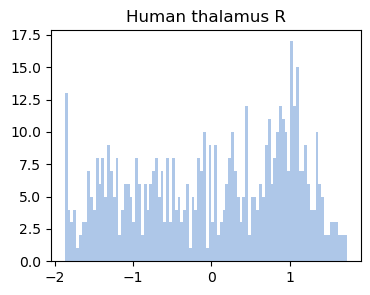

mouse mean: 0.0526 std: 0.0068


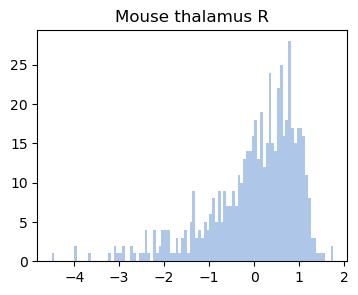

In [6]:

mouse_encodings_folder = "./VAE_train/2d_anat/mouse_train_4/train_latent_encodings/"
human_encodings_folder = "./VAE_train/2d_anat/human_train_4/train_latent_encodings/"

dataset = LatentVectorsVolRatios(mouse_encodings_folder, human_encodings_folder, common_vols=[10])
human_features, mouse_features = dataset.get_features()
human_features_means, human_features_stds = dataset.get_human_mean_and_std()
mouse_features_means, mouse_features_stds = dataset.get_mouse_mean_and_std()
human_features_mins, human_features_maxs = dataset.get_human_features_min_maxes()

human_ratios_means, human_ratios_stds = dataset.get_human_mean_and_std()


# plot dist of ratios to test loader:
num = 1000 # get 1000 random samples
# # non norm
# real_human_features = dataset.get_human_features_non_norm(num)
# real_human_thal_r = real_human_features[:, 0]

# real_mouse_features = dataset.get_mouse_features_non_norm(num)
# real_mouse_thal_r = real_mouse_features[:, 0]

# normalized
real_human_features, real_mouse_features = dataset.get_features()
real_human_thal_r = real_human_features[:, 0]
real_mouse_thal_r = real_mouse_features[:, 0]

print("human mean:", round(human_features_means[0], 4), "std:", round(human_features_stds[0], 4))
bins = 100
plt.figure(figsize=(4,3))
plt.hist(real_human_thal_r, bins=bins, color=repeated_colors[251+10])
plt.title("Human thalamus R")
plt.show()



print("mouse mean:", round(mouse_features_means[0], 4), "std:", round(mouse_features_stds[0], 4))
plt.figure(figsize=(4,3))
plt.hist(real_mouse_thal_r, bins=bins, color=repeated_colors[251+10])
plt.title("Mouse thalamus R")
plt.show()





In [7]:
def plot_img(img):
    print("pca")
    plt.figure(figsize=(2,3))
    plt.imshow(img[0].detach().cpu().numpy().reshape(120, 120), cmap="gray")
    plt.show()

    print("non diff convert")
    print(get_gm_non_diff(img))
    img_non_diff = torch.round(torch.clamp(img, 0, 3))
    plt.figure(figsize=(2,3))
    plt.imshow(img_non_diff[0].detach().cpu().numpy().reshape(120, 120), cmap="gray")
    plt.colorbar()
    plt.show()

    print("diff convert")
    print(get_gm_diff(img))
    min_approx=-0.25
    max_approx=3.35

    img_diff = 3*((img - min_approx) / (max_approx - min_approx))
    plt.figure(figsize=(2,3))
    plt.imshow(img_diff[0].detach().cpu().numpy().reshape(120, 120), cmap="gray")
    plt.colorbar()
    plt.show()


    sigma = 0.3
    prob_gm = torch.exp(-(img_diff - 1)**2 / (2 * sigma**2))
    plt.figure(figsize=(2,3))
    plt.imshow(prob_gm[0].detach().cpu().numpy().reshape(120, 120), cmap="gray")
    plt.colorbar()
    plt.show()

def get_gm_non_diff(img): # ***** FIX

    img = torch.round(torch.clamp(img, 0, 3))
    img = img.view(-1, 120*120*128)
    

    gm_count = torch.sum(img == 1, dim=(1)).float()
    wm_count = torch.sum(img == 2, dim=(1)).float()
    csf_count = torch.sum(img == 3, dim=(1)).float()
    tot_count = gm_count + wm_count + csf_count + 1e-6  # prevent division by zero

    gm_ratio = gm_count / tot_count


    return gm_ratio

def get_gm_diff(img, min_approx=-0.5, max_approx=3.35):
    sigma = 0.35
    img = 3*((img - min_approx) / (max_approx - min_approx))
    img = img.view(-1, 120*120*128)

    soft_mask_1 = torch.exp(-(img - 1)**2 / (2 * sigma**2))
    soft_mask_2 = torch.exp(-(img - 2)**2 / (2 * sigma**2))
    soft_mask_3 = torch.exp(-(img - 3)**2 / (2 * sigma**2))

    gm_count = soft_mask_1.sum(dim=1)
    wm_count = soft_mask_2.sum(dim=1)
    csf_count = soft_mask_3.sum(dim=1)
    tot_count = gm_count + wm_count + csf_count + 1e-6

    gm_ratio = gm_count / tot_count

    return gm_ratio

def get_matter_ratios_diff(img, min_approx=-0.5, max_approx=3.35):
    sigma = 0.35
    img = 3*((img - min_approx) / (max_approx - min_approx))
    img = img.view(-1, 120*120*128)

    soft_mask_1 = torch.exp(-(img - 1)**2 / (2 * sigma**2))
    soft_mask_2 = torch.exp(-(img - 2)**2 / (2 * sigma**2))
    soft_mask_3 = torch.exp(-(img - 3)**2 / (2 * sigma**2))

    gm_count = soft_mask_1.sum(dim=1)
    wm_count = soft_mask_2.sum(dim=1)
    csf_count = soft_mask_3.sum(dim=1)
    tot_count = gm_count + wm_count + csf_count + 1e-6

    gm_ratio = gm_count / tot_count
    wm_ratio = wm_count / tot_count
    csf_ratio = csf_count / tot_count

    return gm_ratio, wm_ratio, csf_ratio

# VOLUME RATIOS
# def get_vol_ratios_diff(imgs, common_vols, sigma=0.35):
#     # imgs.shape = [BS, x, y, num_channels] -> want one value per channel like a softmax

#     # Flatten per volume
#     imgs = imgs.view(imgs.shape[0], -1)  # (batch, voxels)
    
#     # Structure labels to check (251 → 270 inclusive)
#     common_struct_idxs = torch.arange(251, 271, device=imgs.device)
    
#     # Only keep the selected structures
#     struct_idxs = common_struct_idxs[common_vols]
    
#     # Total voxels per volume
#     background_val = 0
#     background_soft_mask = torch.exp(-(imgs - background_val)**2 / (2 * sigma**2))
#     total_count = imgs.shape[1] - background_soft_mask.sum(dim=1)
    
#     vol_ratios_list = []
#     for struct_idx in struct_idxs:
#         # Count how many voxels equal this structure label per volume
#         struct_soft_mask = torch.exp(-(imgs - struct_idx)**2 / (2 * sigma**2))
#         struct_count = struct_soft_mask.sum(dim=1)

#         ratio_per_vol = struct_count / total_count
#         vol_ratios_list.append(ratio_per_vol)
    
#     # Stack into shape (num_structs, batch)
#     vol_ratios = torch.stack(vol_ratios_list, dim=0)
#    return vol_ratios

def get_vol_ratios_diff(imgs, common_vols):
    #print(imgs.shape)  # e.g. [BS, 271, 120, 120]

    # Flatten spatial dimensions
    imgs = imgs.view(imgs.shape[0], imgs.shape[1], -1)  # [BS, num_channels, voxels]

    # Select structure indices
    common_struct_idxs = torch.arange(251, 271, device=imgs.device)
    struct_idxs = common_struct_idxs[common_vols]

    background_val = 0
    imgs = torch.softmax(imgs, dim=1)
    back_count = torch.sum(imgs[:,background_val,:], dim=1)
    total_count = imgs.shape[-1] - back_count

    vol_ratios_list = []
    for struct_idx in struct_idxs:
        struct_count = torch.sum(imgs[:,struct_idx,:], dim=1)
        ratio_per_vol = struct_count / total_count
        vol_ratios_list.append(ratio_per_vol)

    # Stack and permute to [BS, num_structs]
    vol_ratios = torch.stack(vol_ratios_list, dim=1)

    return vol_ratios


def get_vol_ratios_non_diff(imgs, common_vols):
    imgs = torch.argmax(imgs, dim=1).reshape(-1, 120*120)

    total_counts = torch.sum(imgs != 0, dim=1)

    # Structure labels to check (251 → 270 inclusive)
    common_struct_idxs = torch.arange(251, 271)
    
    # Only keep the selected structures
    struct_idxs = common_struct_idxs[common_vols]

    vol_ratios = []
    for struct_idx in struct_idxs:
        struct_counts = (imgs == struct_idx).sum(dim=1).float()
        vol_ratios.append(torch.where(total_counts == 0, torch.zeros_like(struct_counts), struct_counts / total_counts))
    
    vol_ratios = torch.stack(vol_ratios, dim=1).cuda()
    return vol_ratios



In [8]:
# TRAIN
# Test out different models to learn the mapping between latent vectors
import csv
import pickle

# mouse_encodings_folder = "./save_anat_e_d/mouse_train_3/train_latent_encodings/"
# human_encodings_folder = "./save_anat_e_d/human_train_3/train_latent_encodings/"

# mouse_test_encodings_folder = "./save_anat_e_d/mouse_train_3/test_latent_encodings/"
# human_test_encodings_folder = "./save_anat_e_d/human_train_3/test_latent_encodings/"4

common_vols = [0, 1, 4, 5, 10, 11, 16, 17, 18, 19] # [10, 11] # thalumus

mouse_encodings_folder = "./VAE_train/2d_anat/mouse_train_4/train_m_v_encodings/"
human_encodings_folder = "./VAE_train/2d_anat/human_train_4/train_m_v_encodings/"

mouse_test_encodings_folder = "./VAE_train/2d_anat/mouse_train_4/test_m_v_encodings/"
human_test_encodings_folder = "./VAE_train/2d_anat/human_train_4/test_m_v_encodings/"

dataset = LatentVectorsVolRatios(mouse_encodings_folder, human_encodings_folder, common_vols=common_vols)
human_ratios_means, human_ratios_stds = dataset.get_human_mean_and_std()

batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

valdataset = LatentVectorsVolRatios(mouse_test_encodings_folder, human_test_encodings_folder, common_vols=common_vols)
valloader = DataLoader(valdataset, batch_size=batch_size, shuffle=True, num_workers=4)

model = MLP.cuda() #ElementWiseLinear(latent_len).cuda()  # move to GPU
#model.load_state_dict(torch.load('./pca/gm_loss_mod_500.pth')['model_state_dict'])

criterion = nn.MSELoss()

def calc_KLD(means, log_vars):
    #num_voxels = 120*120*128 # NOTE: update for 3D
    num_voxels = 120*120 # NOTE: update for 3D
    KLD = (-0.5 * torch.sum(1 + log_vars - means.pow(2) - log_vars.exp())) / (num_voxels * batch_size)
    return KLD

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
#optimizer.load_state_dict(torch.load('./pca/gm_loss_mod_500.pth')['optimizer_state_dict'])

csv_path = "./VAE_train/2d_anat/mapping/loss.csv"
mode = 'w' # 'w' -> overwrite, 'a' -> append


if mode == 'w': # new file
    with open(csv_path, mode=mode, newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "loss", "val_loss", "train_mse_loss", "val_mse_loss", "train_loss_s1_diff", "val_loss_s1_diff", "train_loss_s1_non_diff", "val_loss_s1_non_diff"])


# Human decoder to translate the mapped latent encoding - to evaluate objective
decoder_save_folder = "./VAE_train/2d_anat/human_train_4/"
decoder_epoch = 200
decoder_trans = Decoder_VAE(n_upsample=2, n_res=4, dim=32, output_dim=271).cuda()
decoder_trans.load_state_dict(torch.load(decoder_save_folder + "checkpoint_epoch_" + str(decoder_epoch))['decoder_state_dict'])

# FREEEEZE parameters so it's not trained!!
for param in decoder_trans.parameters():
    param.requires_grad = False
decoder_trans.eval()


# Training loop
start_epoch = 0
epochs = 1000
save_loss = []
epsilon = 1e-6
alpha = 0.001 # ratio preservation
beta = 1 # MSE 
gamma = 0
pca_encodings = []

print("start training!!")
for epoch in range(start_epoch, epochs + start_epoch):
    model.train()

    train_loss = 0.0
    train_loss_s1_non_diff = 0.0
    train_loss_s1_diff = 0.0
    train_mse_loss = 0.0
    train_KLD = 0.0
    for mouse_batch, human_batch, mouse_features_batch in dataloader:

        mouse_batch = torch.cat([mouse_batch[0].cuda(), mouse_batch[1].cuda()], dim=2).squeeze()
        human_batch = [human_batch[0].cuda(), human_batch[1].cuda()]
        mouse_features_batch = mouse_features_batch.cuda()

        #print("mouse_batch:", mouse_batch.shape)
        human_out = model(mouse_batch)
        #print("human_out:", human_out.shape)

        u = human_out[:, :latent_len]
        std = human_out[:, latent_len:]

        #print("std:", std.shape)

        human_z = reparameterization(u, std)
        #print("human_z:", human_z.shape)


        optimizer.zero_grad()

        recon_imgs = decoder_trans(human_z)
        #print("recon_imgs:", recon_imgs.shape)


        vols_diff = get_vol_ratios_diff(recon_imgs, common_vols)
        vols_non_diff = get_vol_ratios_non_diff(recon_imgs, common_vols)

        vols_norm_diff = (vols_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)
        vols_norm_non_diff = (vols_non_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)
    
        mse_loss = criterion(u, human_batch[0].squeeze()) +  criterion(std, human_batch[1].squeeze()) # mse(means) + mse(vars)
        #mse_loss = criterion(human_out, human_batch)

        vols_loss_diff = torch.mean(torch.abs(mouse_features_batch - vols_norm_diff), dim=1)

        vols_loss_non_diff = torch.mean(torch.abs(mouse_features_batch - vols_norm_non_diff), dim=1) # non diff

        loss_s1_diff = vols_loss_diff[0]
        loss_s1_non_diff = vols_loss_non_diff[0]

        loss_s2_diff = vols_loss_diff[1]
        loss_s2_non_diff = vols_loss_non_diff[1]

        tot_vol_loss = torch.sum(vols_loss_diff)

        KLD = calc_KLD(u, std)
        loss = beta*mse_loss + alpha*(tot_vol_loss) + gamma*KLD

        loss.backward()
        optimizer.step()

        train_mse_loss += mse_loss.item() * mouse_batch.size(0)
        train_loss_s1_diff += loss_s1_diff.item() * mouse_batch.size(0)
        train_loss_s1_non_diff += loss_s1_non_diff.item() * mouse_batch.size(0)
        train_loss += loss.item() * mouse_batch.size(0)
        train_KLD += KLD.item() * mouse_batch.size(0)
        

    train_mse_loss = train_mse_loss / len(dataset)
    train_loss_s1_diff = train_loss_s1_diff / len(dataset)
    train_loss_s1_non_diff = train_loss_s1_non_diff / len(dataset)
    train_loss = train_loss / len(dataset)
    train_KLD = train_KLD / len(dataset)

    model.eval()
    val_loss = 0.0
    val_mse_loss = 0.0
    val_loss_s1_non_diff = 0.0
    val_loss_s1_diff = 0.0
    val_KLD = 0.0
    
    for mouse_batch, human_batch, mouse_features_batch in valloader:
        mouse_batch = torch.cat([mouse_batch[0].cuda(), mouse_batch[1].cuda()], dim=2).squeeze()
        human_batch = [human_batch[0].cuda(), human_batch[1].cuda()]
        mouse_features_batch = mouse_features_batch.cuda()

        human_out = model(mouse_batch)

        u = human_out[:, :latent_len]
        std = human_out[:, latent_len:]

        human_z = reparameterization(u, std)

        optimizer.zero_grad()

        recon_imgs = decoder_trans(human_z)


        vols_diff = get_vol_ratios_diff(recon_imgs, common_vols)
        vols_non_diff = get_vol_ratios_non_diff(recon_imgs, common_vols)

        vols_norm_diff = (vols_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)
        vols_norm_non_diff = (vols_non_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)
    
        #print("u:", u.shape)
        #print("human_batch[0]:", human_batch[0].squeeze().shape)

        mse_loss = criterion(u, human_batch[0].squeeze()) +  criterion(std, human_batch[1].squeeze()) # mse(means) + mse(vars)
        #mse_loss = criterion(human_out, human_batch)

        loss_s1_diff = vols_loss_diff[0]
        loss_s1_non_diff = vols_loss_non_diff[0]

        loss_s2_diff = vols_loss_diff[1]
        loss_s2_non_diff = vols_loss_non_diff[1]

        tot_vol_loss = torch.sum(vols_loss_diff)

        KLD = calc_KLD(u, std)
        loss = beta*mse_loss + alpha*(tot_vol_loss) + gamma*KLD

        val_mse_loss += mse_loss.item() * mouse_batch.size(0)
        val_loss_s1_diff += loss_s1_diff.item() * mouse_batch.size(0)
        val_loss_s1_non_diff += loss_s1_non_diff.item() * mouse_batch.size(0)
        val_loss += loss.item() * mouse_batch.size(0)
        val_KLD += KLD.item() * mouse_batch.size(0)
        

    val_mse_loss = val_mse_loss / len(valdataset)
    val_loss_s1_diff = val_loss_s1_diff / len(valdataset)
    val_loss_s1_non_diff = val_loss_s1_non_diff / len(valdataset)
    val_loss = val_loss / len(valdataset)
    val_KLD = val_KLD / len(valdataset)

    print(f"Epoch {epoch + 1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Train mse: {train_mse_loss:.6f}, Val mse: {val_mse_loss:.6f}, Train s1: {train_loss_s1_diff:.6f}, Val s1: {val_loss_s1_diff:.6f}, Train KLD: {train_KLD:.6f}")

    with open(csv_path, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch, train_loss, val_loss, train_mse_loss, val_mse_loss, train_loss_s1_diff, val_loss_s1_diff, train_loss_s1_non_diff, val_loss_s1_non_diff])


# 1000 takes ~ 7 min
# with 1024 + BS=2 -> 1 epoch takes ~

start training!!
Epoch 1, Train Loss: 0.790424, Val Loss: 0.586919, Train mse: 0.649408, Val mse: 0.568302, Train s1: 2.184075, Val s1: 1.225313, Train KLD: 0.134844
Epoch 2, Train Loss: 0.592161, Val Loss: 0.420875, Train mse: 0.504122, Val mse: 0.406263, Train s1: 1.472850, Val s1: 1.264581, Train KLD: 0.105259
Epoch 3, Train Loss: 0.411206, Val Loss: 0.276730, Train mse: 0.332871, Val mse: 0.260243, Train s1: 1.465245, Val s1: 0.785666, Train KLD: 0.069373
Epoch 4, Train Loss: 0.279760, Val Loss: 0.179037, Train mse: 0.203329, Val mse: 0.164265, Train s1: 1.376138, Val s1: 1.120897, Train KLD: 0.041160
Epoch 5, Train Loss: 0.203793, Val Loss: 0.124657, Train mse: 0.127309, Val mse: 0.110019, Train s1: 1.154718, Val s1: 0.971422, Train KLD: 0.023984
Epoch 6, Train Loss: 0.163180, Val Loss: 0.089651, Train mse: 0.088125, Val mse: 0.078168, Train s1: 1.147916, Val s1: 0.934997, Train KLD: 0.015463
Epoch 7, Train Loss: 0.141565, Val Loss: 0.075925, Train mse: 0.066683, Val mse: 0.060225

KeyboardInterrupt: 

In [ ]:
err

NameError: name 'err' is not defined

In [ ]:
# save the mapping model
#errr
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch
}, './VAE_train/2d_anat/mapping/ratio_mapper_2.pth')


66 0.0385


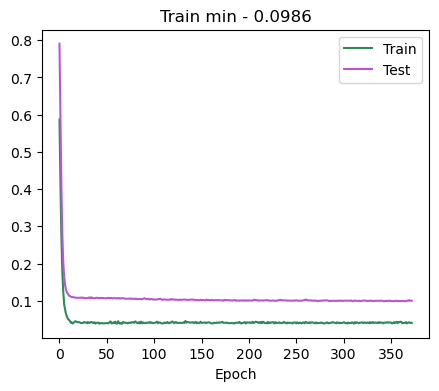

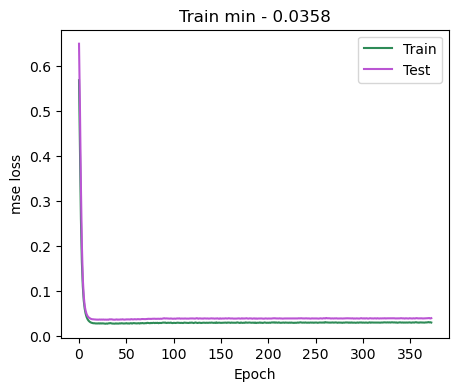

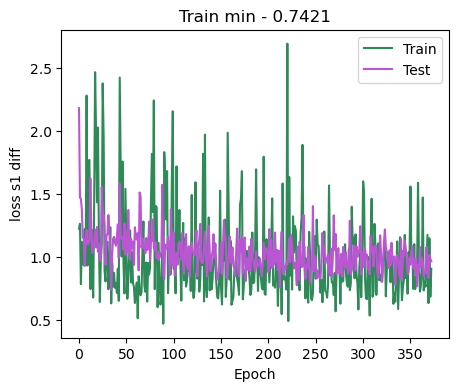

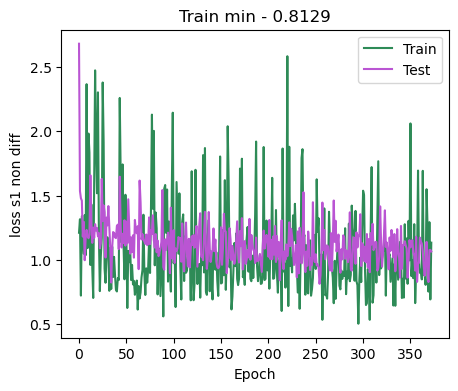

train_loss_s1_diff
train_loss_s1_non_diff


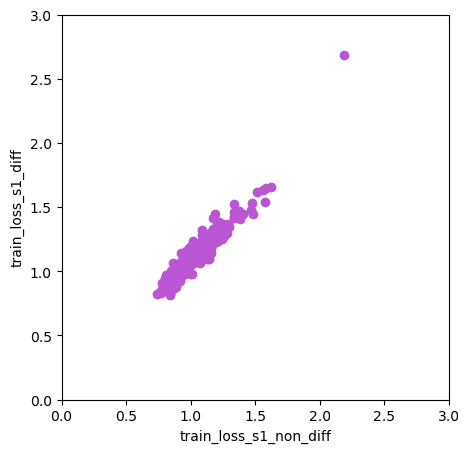

val_loss_s1_diff
val_loss_s1_non_diff


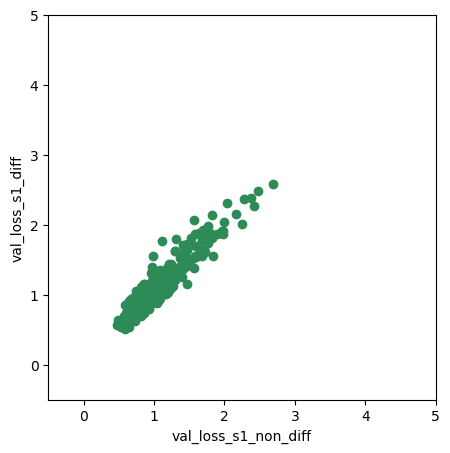

In [9]:
# 1. Plot loss
loss = pd.read_csv("./VAE_train/2d_anat/mapping/loss.csv")
#test_loss = pd.read_csv("./save_models/human_train_1/test_loss_log.csv")

min_test = loss.iloc[:, 0][np.argmin(loss.iloc[:, 2])]
print(min_test, round(np.min(loss.iloc[:, 2]), 4))

idx = 1

for title in loss.keys()[idx:][::2]:
    plt.figure(figsize=(5,4))
    plt.plot(loss.iloc[:, idx + 1], color="seagreen")
    plt.plot(loss.iloc[:, idx], color="mediumorchid")
    plt.xlabel("Epoch")
    plt.ylabel(" ".join(title.split("_")[1:]))
    plt.legend(["Train", "Test"])
    plt.title("Train min - " + str(round(np.min(loss.iloc[:, idx]), 4)))
    #plt.axvline(min_test, color="grey")
    plt.show()

    idx += 2

print(loss.keys()[5])
print(loss.keys()[7])
plt.figure(figsize=(5,5))
plt.scatter(loss.iloc[:, 5], loss.iloc[:, 7], color="mediumorchid")
plt.xlabel("train_loss_s1_non_diff")
plt.ylabel("train_loss_s1_diff")
plt.xlim((0,3))
plt.ylim((0,3))
plt.show()

print(loss.keys()[6])
print(loss.keys()[8])
plt.figure(figsize=(5,5))
plt.scatter(loss.iloc[:, 6], loss.iloc[:, 8], color="seagreen")
plt.xlabel("val_loss_s1_non_diff")
plt.ylabel("val_loss_s1_diff")
plt.xlim((-0.5,5))
plt.ylim((-0.5,5))
plt.show()


In [10]:
def reparameterization(means, log_vars, deterministic=False):
    if deterministic:
        return means
    
    # move random vars sampled from a normal dist to size log_vars to device
    epsilon = torch.randn_like(log_vars)
    std = torch.exp(0.5 * log_vars)
    z = means + std * epsilon
    return z

In [11]:
# Now test the translating model!!!
# (for a sample decode to reconstructed and transaated - with model trained above)

# model = MLP.cuda()
# model.load_state_dict(torch.load('./VAE_train/2d_anat/mapping/ratio_mapper_1.pth')['model_state_dict'])

# folder with model checkpoints
encoder_save_folder = "./VAE_train/2d_anat/mouse_train_4/"
decoder_save_folder = "./VAE_train/2d_anat/human_train_4/"

# checkpoint to load
encoder_epoch = 150
decoder_epoch = 200

#folder to save translated images to
save_path = "./VAE_train/2d_anat/mapping/z_mapper_trans/"
os.makedirs(save_path, exist_ok=True)

# Initialize model
encoder = Encoder_VAE(n_downsample=2, n_res=4, input_dim=1, dim=8, norm='in', activ='relu', pad_type='zero')
decoder_recon = Decoder_VAE(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=271)
decoder_trans = Decoder_VAE(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=271)

# load models checkpoint to test
encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])
decoder_recon.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['decoder_state_dict'])
decoder_trans.load_state_dict(torch.load(decoder_save_folder + "checkpoint_epoch_" + str(decoder_epoch))['decoder_state_dict'])

encoder.eval()
decoder_recon.eval()
decoder_trans.eval()
model.eval()

# # load pca and scaler
# with open('./pca/anat_2d/14000_comp_scaler_mouse.pkl', 'rb') as f:
#     scaler_mouse = pickle.load(f)

# with open('./pca/anat_2d/14000_comp_pca_mouse.pkl', 'rb') as f:
#     pca_mouse = pickle.load(f)

# with open('./pca/anat_2d/14000_comp_scaler_human.pkl', 'rb') as f:
#     scaler_human = pickle.load(f)

# with open('./pca/anat_2d/14000_comp_pca_human.pkl', 'rb') as f:
#     pca_human = pickle.load(f)

vol_ratios_diff = []
vol_ratios_non_diff = []
vol_ratios_norm_diff = []
vol_ratios_norm_non_diff = []


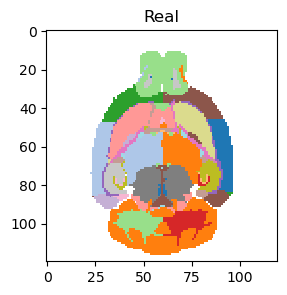

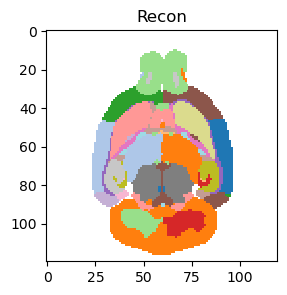

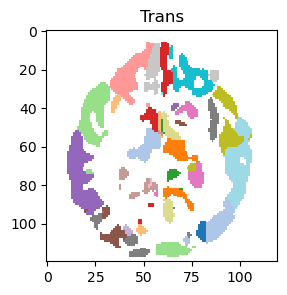

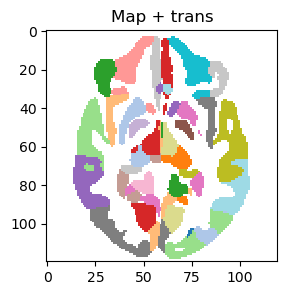

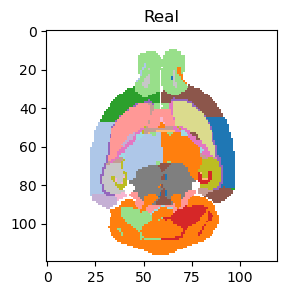

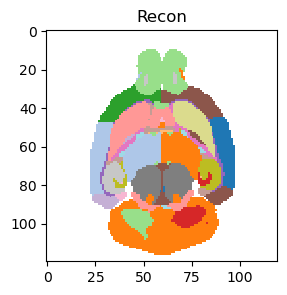

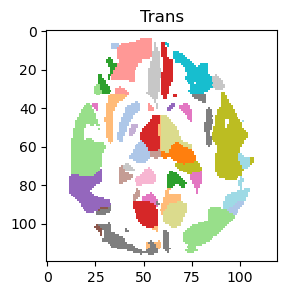

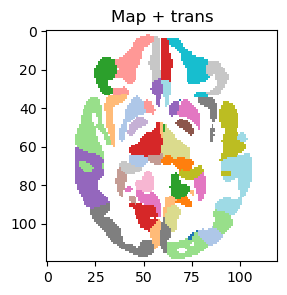

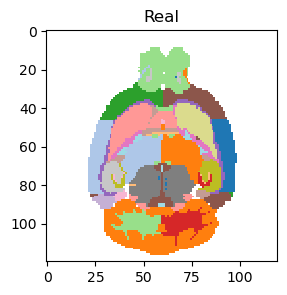

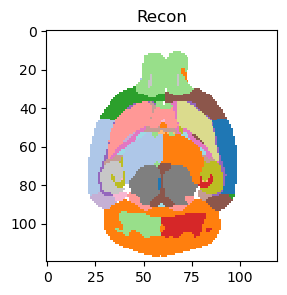

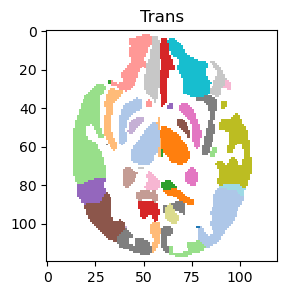

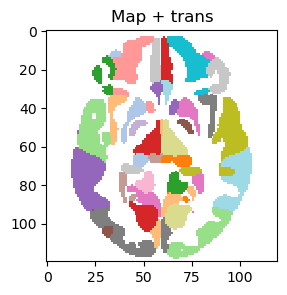

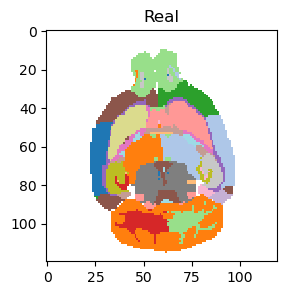

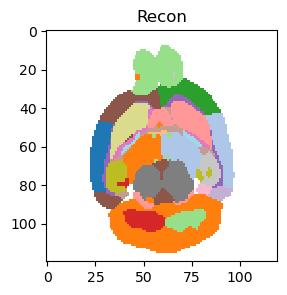

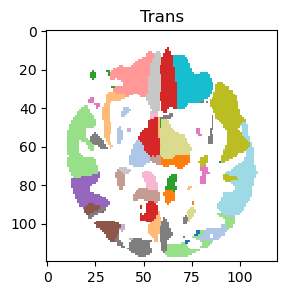

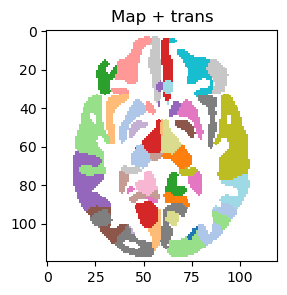

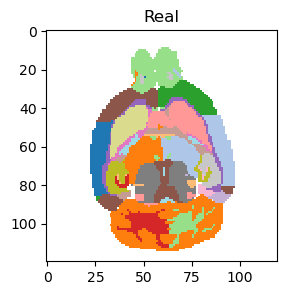

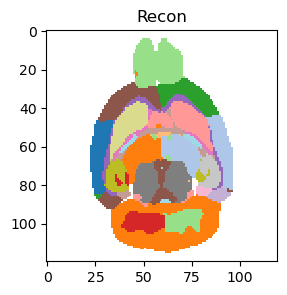

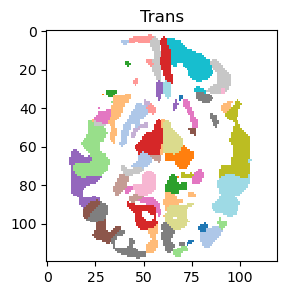

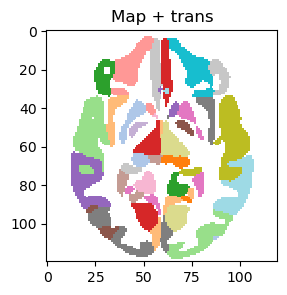

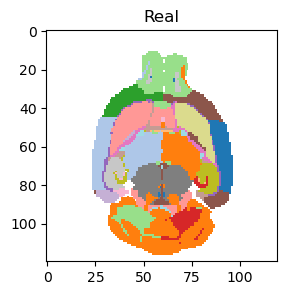

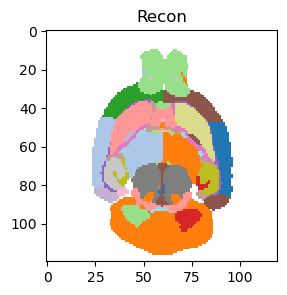

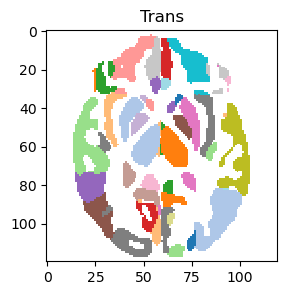

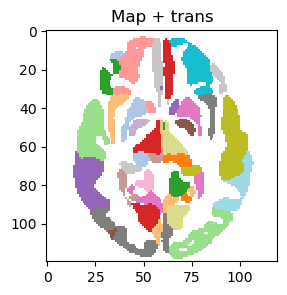

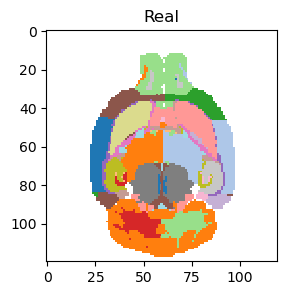

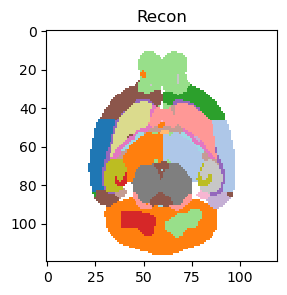

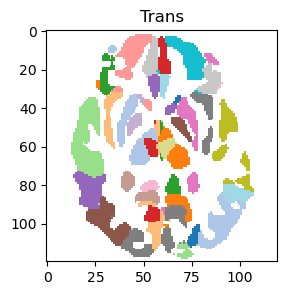

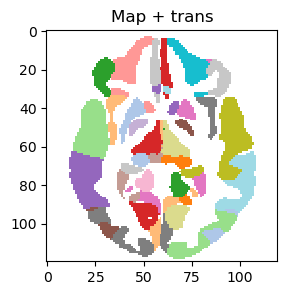

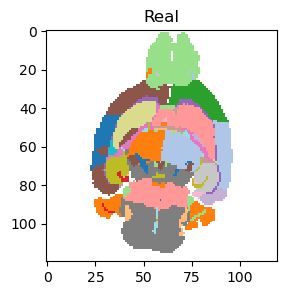

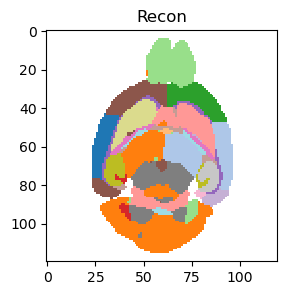

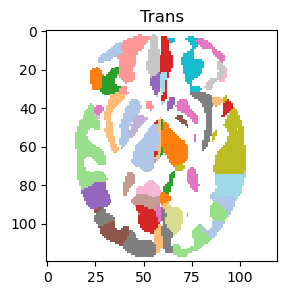

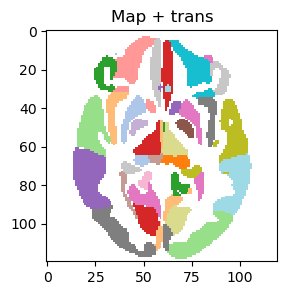

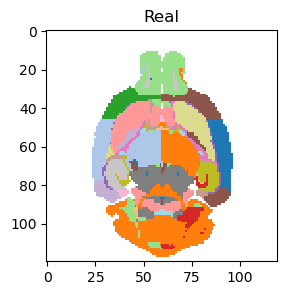

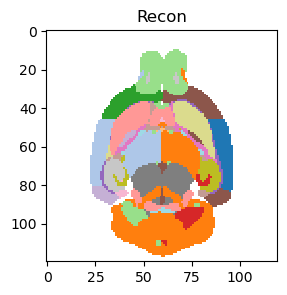

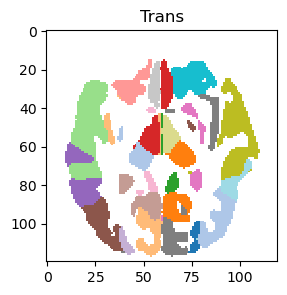

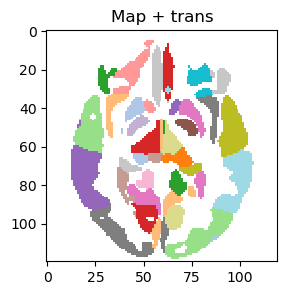

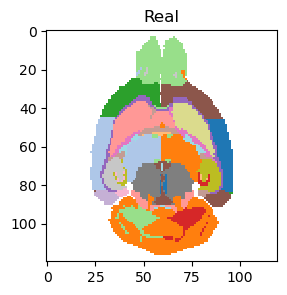

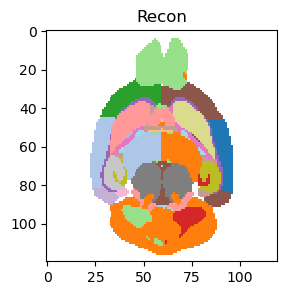

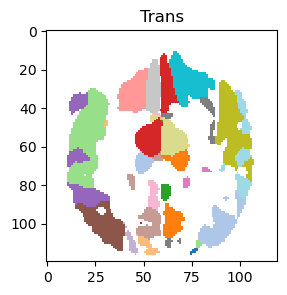

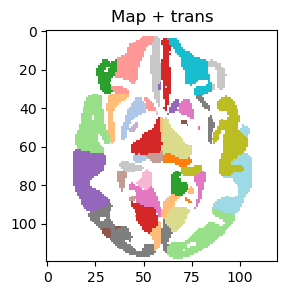

In [16]:
# Encode with mouse encoder and decode with human decoder
test_folder = "./datasets/anat_2d/mouse_test/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]
random.seed(0)
random.shuffle(test_paths)
idxs = np.arange(len(test_paths))

trans_imgs = []

common_vols = [10]

for idx in idxs[:10]:

    img = sitk.ReadImage(test_paths[idx])
    img_arr = sitk.GetArrayFromImage(img)
    img_arr = np.expand_dims(img_arr, axis=0)
    img_torch = torch.from_numpy(img_arr).to(torch.float)
    

    #img_arr_flat = img_arr.reshape(1, len(img_arr)**2)
    #print(img_arr_flat.shape)

    # NOTE: PCA
    # mouse_test_scaled = scaler_mouse.transform(img_arr_flat)
    # mouse_test_pca = pca_mouse.transform(mouse_test_scaled)

    # human_encoding = model(torch.from_numpy(mouse_test_pca).cuda())

    # # to human
    # human_train_recon = pca_human.inverse_transform(human_encoding.detach().cpu().numpy())
    # human_train_recon_unscale = scaler_human.inverse_transform(human_train_recon)
    # trans_map_img = np.clip(np.round(human_train_recon_unscale.reshape(img_arr.shape)), 0, 270) # reshape to 2D imgs


    # AE/VAE
    means, log_vars = encoder(img_torch.unsqueeze(0))
    # get latent vectors - sampled from learned dists
    z = reparameterization(means, log_vars)

    #recon = decoder(z)

    # the translating model trained above
    s_m_trans = model(torch.concat([means, log_vars], dim=1).cuda()).cpu() #*human_stds + human_means

    # de-normalize before reshaping
    z_trans = reparameterization(s_m_trans[:, :latent_len], s_m_trans[:, latent_len:])

    recon_img = decoder_recon(z)
    recon_img = torch.argmax(recon_img, dim=1)
    recon_img = np.array(recon_img.squeeze())

    trans_img = decoder_trans(z)

    trans_img = torch.argmax(trans_img, dim=1)
    trans_img = np.array(trans_img.squeeze())

    trans_map_img = decoder_trans(z_trans.detach().cpu().reshape(z.shape))

    # vols_diff = get_vol_ratios_diff(trans_map_img, common_vols).detach().cpu().numpy()[0,0]
    # vols_non_diff = get_vol_ratios_non_diff(trans_map_img, common_vols).detach().cpu().numpy()[0,0]

    # print("vol ratios diff:", vols_diff)
    # print("vol ratios non diff:", vols_non_diff)
    
    # vols_norm_diff = (vols_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)
    # vols_norm_non_diff = (vols_non_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)

    # print("vols_norm_diff", vols_norm_diff)
    # print("vols_norm_non_diff", vols_norm_non_diff)

    # vol_ratios_diff.append(vols_diff)
    # vol_ratios_non_diff.append(vols_non_diff)

    # vol_ratios_norm_diff.append(vols_norm_diff)
    # vol_ratios_norm_non_diff.append(vols_norm_non_diff)


    trans_map_img = torch.argmax(trans_map_img, dim=1)
    trans_map_img = np.array(trans_map_img.squeeze())

    slice_idx = 0
    size = 3
    plot_seg(img_arr, slice_idx, size, "Real")
    plot_seg([recon_img], slice_idx, size, "Recon")
    plot_seg([trans_img], slice_idx, size, "Trans")
    plot_seg([trans_map_img], slice_idx, size, "Map + trans")

    trans_imgs.append(trans_map_img)

    # trans_map_niffty = sitk.GetImageFromArray(trans_map_img)

    # sitk.WriteImage(trans_map_niffty, save_path + "trans_" + test_paths[idx].split("/")[-1])

(168,)
(168,)


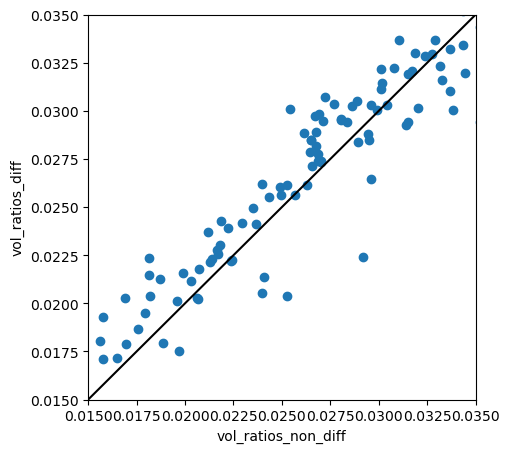

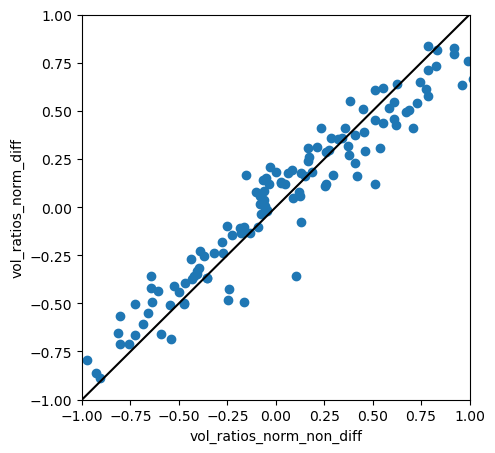

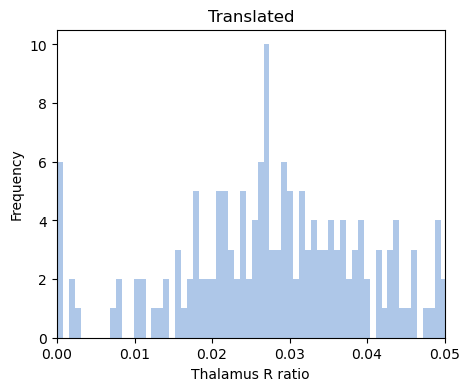

In [ ]:
print(np.array(vol_ratios_non_diff).shape)
print(np.array(vol_ratios_diff).shape)

plt.figure(figsize=(5,5))
plt.scatter(vol_ratios_non_diff, vol_ratios_diff)
plt.plot(np.arange(-5, 5), np.arange(-5, 5), color="black")
plt.xlabel("vol_ratios_non_diff")
plt.ylabel("vol_ratios_diff")
plt.xlim((0.015, 0.035)) # should be ~0 -> 0.05
plt.ylim((0.015, 0.035))
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(vol_ratios_norm_non_diff, vol_ratios_norm_diff)
plt.plot(np.arange(-5, 5), np.arange(-5, 5), color="black")
plt.xlabel("vol_ratios_norm_non_diff")
plt.ylabel("vol_ratios_norm_diff")
plt.xlim((-1, 1))
plt.ylim((-1, 1))
plt.show()

plt.figure(figsize=(5,4))
plt.hist(vol_ratios_non_diff, color=repeated_colors[251+10], bins=100)
plt.title("Translated")
plt.xlabel("Thalamus R ratio")
plt.ylabel("Frequency")
plt.xlim((0,0.05))
plt.show()



In [13]:
def get_vol_ratio(img_arr):
    vol_ratios = []
    total_count = np.sum(img_arr != 0)

    for i in range(251, 270 + 1):
        vol_ratios.append(0 if total_count == 0 else np.sum(img_arr == i) / total_count)

    return vol_ratios

def compute_common_vol_ratios_from_paths(img_paths):

    vol_ratios = []
    for img_path in img_paths:
        img = sitk.ReadImage(img_path)
        img_arr = sitk.GetArrayFromImage(img)
        vol_ratios.append(get_vol_ratio(img_arr))

    vol_ratios = np.vstack(vol_ratios)

    return vol_ratios

def compute_common_vol_ratios_from_imgs(imgs):

    vol_ratios = []
    for img in imgs:
        vol_ratios.append(get_vol_ratio(img))

    vol_ratios = np.vstack(vol_ratios)

    return vol_ratios

def plot_vol_ratios(real_vol_ratios, synth_vol_ratios, struct_names):
    
    common_struct_colors = repeated_colors[251:]
    bins = 50

    fig2, axs2 = plt.subplots(2, 10, figsize=(35, 6))

    for plot_index in range(2):  # Two sets: 0–9 and 10–19
        fig, axs = plt.subplots(2, 10, figsize=(30, 5))
        
        for i in range(10):
            struct_i = plot_index * 10 + i
            if struct_i >= len(struct_names):
                break
            
            color = common_struct_colors[struct_i]

            real_data = real_vol_ratios[:, struct_i]
            synth_data = synth_vol_ratios[:, struct_i]
            combined_min = min(np.min(real_data), np.min(synth_data))
            combined_max = max(np.max(real_data), np.max(synth_data))
            if combined_min == combined_max:
                continue

            # analyze matter preservation

            r, p = scipy.stats.pearsonr(real_data, synth_data)

            # # try scaling first???
            # from sklearn.preprocessing import StandardScaler

            # scaler = StandardScaler()
            # arr1_scaled = scaler.fit_transform(real_data.reshape(-1, 1)).flatten()
            # arr2_scaled = scaler.fit_transform(synth_data.reshape(-1, 1)).flatten()

            # r, p = scipy.stats.pearsonr(arr1_scaled, arr2_scaled)

            real_reshape = np.array(real_data).reshape(-1, 1)
            synth_reshape = np.array(synth_data).reshape(-1, 1)
            model = LinearRegression().fit(real_reshape, synth_reshape)

            # Predict y values for the regressed line
            y_pred = model.predict(real_reshape)

            axs2[plot_index, i].scatter(real_data, synth_data, color=color)
            axs2[plot_index, i].plot(real_data, y_pred, color="black")
            #axs2[plot_index, i].set_xlim(combined_min*0.90, combined_max*1.03)
            #axs2[plot_index, i].set_ylim(combined_min*0.90, combined_max*1.03)
            axs2[plot_index, i].set_title(struct_names[struct_i] + "(pearsons r=" + str(round(r, 2)) + ")", fontsize=8)

            # plot target idx in black
            #axs2[plot_index, i].scatter(real_data[img_idx], synth_data[img_idx], color='black', s=100)


            bin_edges = np.linspace(combined_min, combined_max, bins + 1)
        
            # Real
            #axs[0, i].set_xlim(combined_min*0.95, combined_max*1.05)
            axs[0, i].hist(real_vol_ratios[:, struct_i], bins=bin_edges, color=color)
            axs[0, i].set_title(struct_names[struct_i], fontsize=8)
            axs[0, i].tick_params(labelsize=6)

            # Synthetic
            #axs[1, i].set_xlim(combined_min*0.95, combined_max*1.05)
            axs[1, i].hist(synth_vol_ratios[:, struct_i], bins=bin_edges, color=color)
            axs[1, i].tick_params(labelsize=6)

        axs[0, 0].set_ylabel("Real vol ratios", fontsize=10)
        axs[1, 0].set_ylabel("Recon vol ratios", fontsize=10)

        fig.tight_layout()
        fig.show()

    fig2.tight_layout()
    fig2.show()


struct_names = ['lateral ventricle', 'basal forebrain', 'hippocampus', 'amygdala', 'fourth ventricle', 'thalamus', 'third ventricle', 'arbor vita of cerebellum', 'nucleus accumbens', 'globus pallidus']
struct_names = [[struct_name + " R", struct_name + " L"] for struct_name in struct_names]
struct_names = [n for pair in struct_names for n in pair]



/home/jessica-bohm/anaconda3/envs/brain_align/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/jessica-bohm/anaconda3/envs/brain_align/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


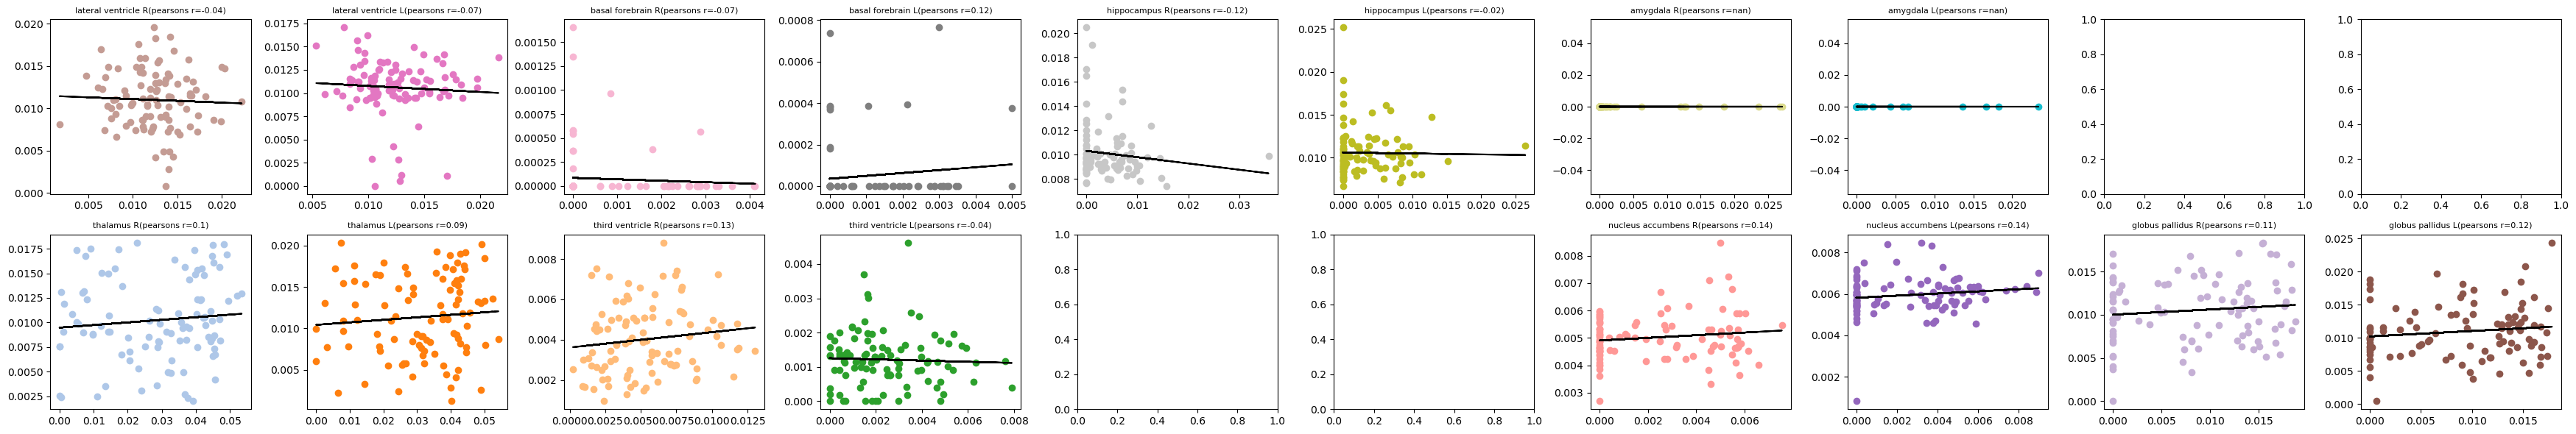

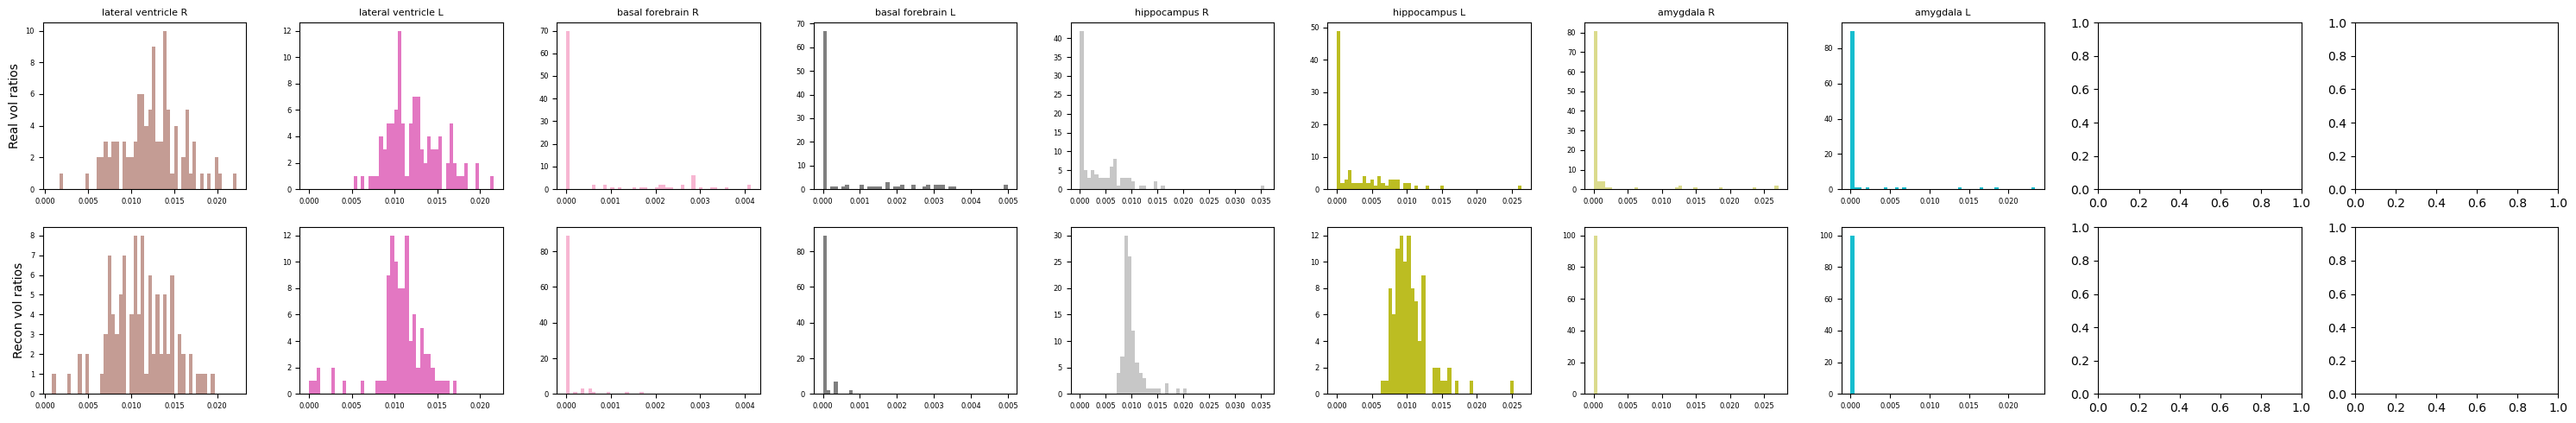

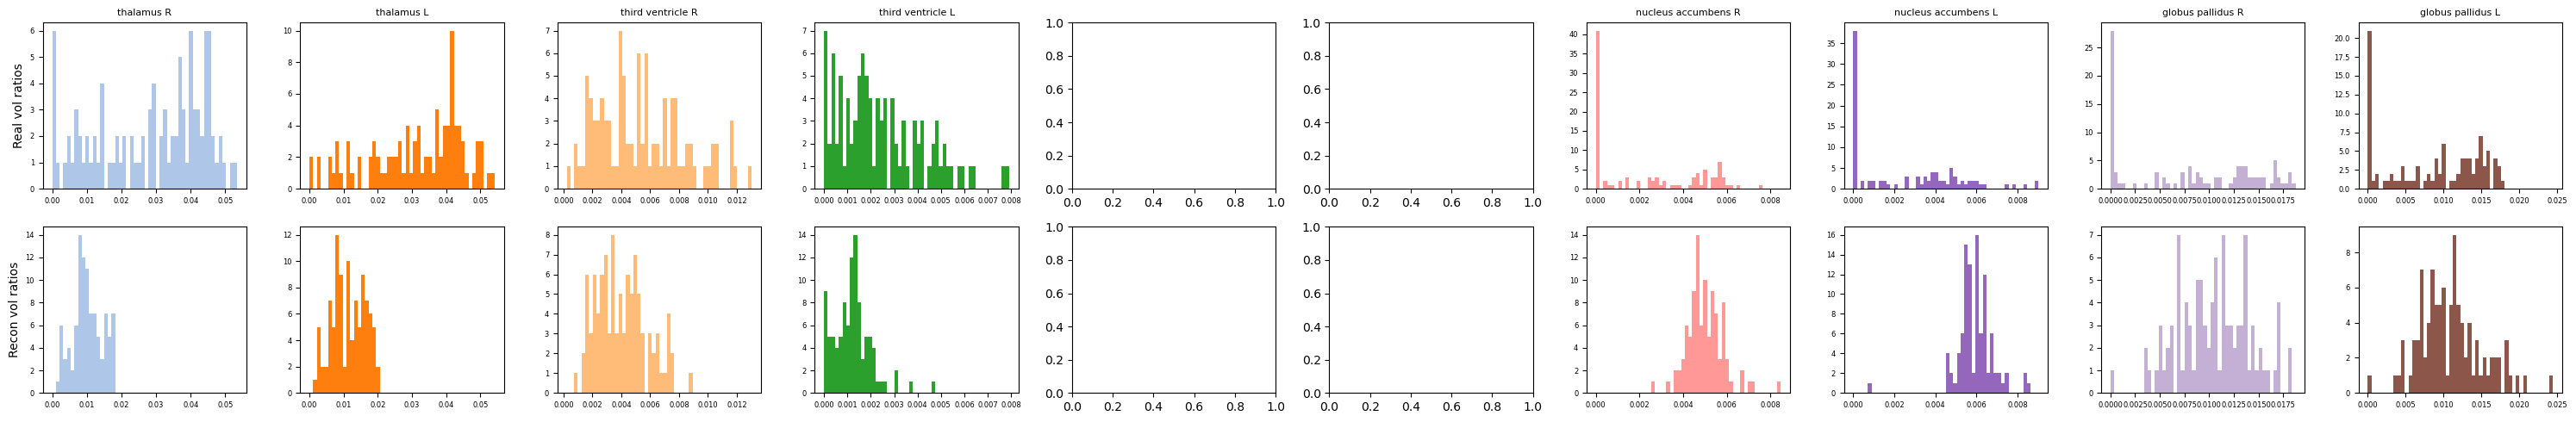

In [14]:
# HUMAN VS HUMAN
human_test_paths = ["./datasets/anat_2d/human_test/" + file_name for file_name in os.listdir("./datasets/anat_2d/human_test/")[:100]]
real_vol_ratios = compute_common_vol_ratios_from_paths(human_test_paths)
recon_vol_ratios = compute_common_vol_ratios_from_imgs(trans_imgs)

plot_vol_ratios(real_vol_ratios, recon_vol_ratios, struct_names)

/home/jessica-bohm/anaconda3/envs/brain_align/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/jessica-bohm/anaconda3/envs/brain_align/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/jessica-bohm/anaconda3/envs/brain_align/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/jessica-bohm/anaconda3/envs/brain_align/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/je

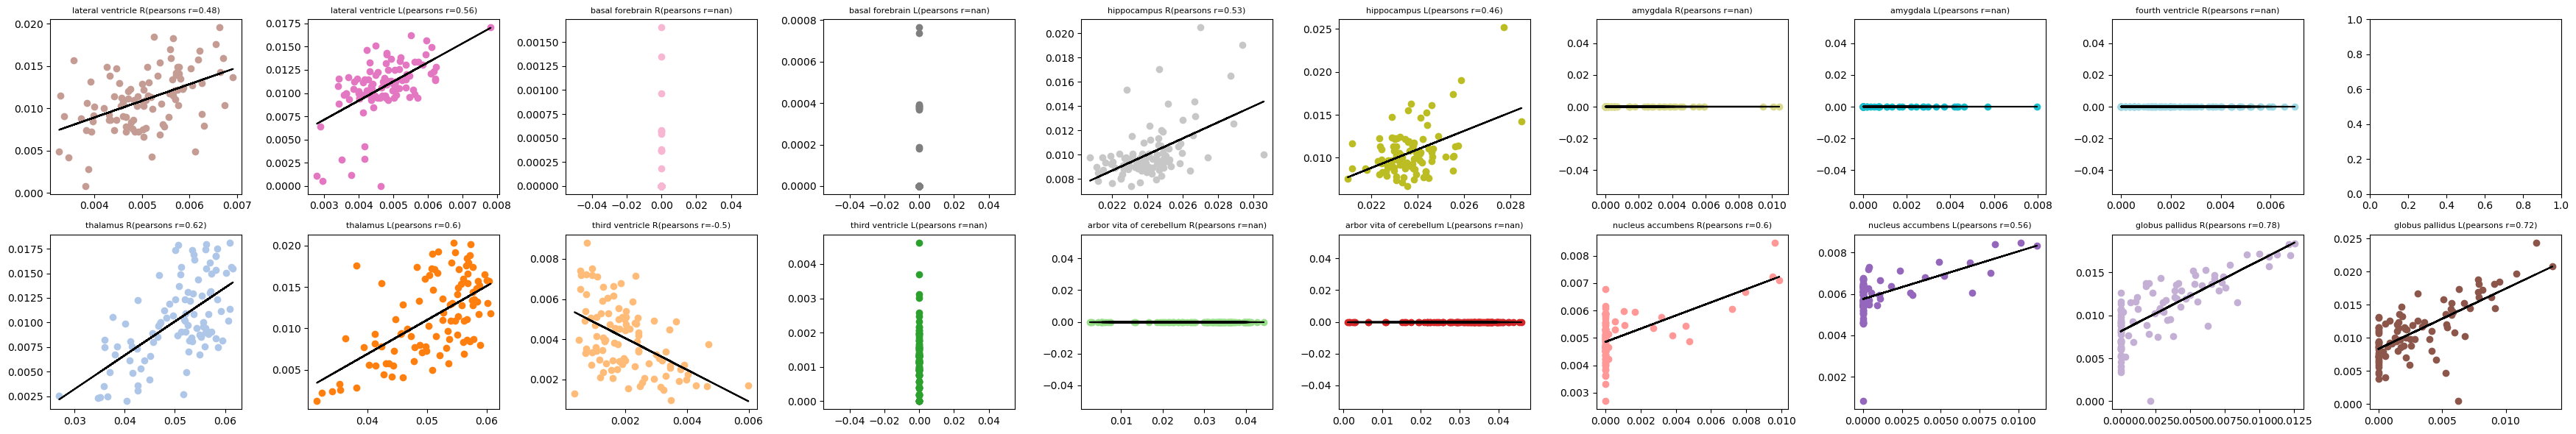

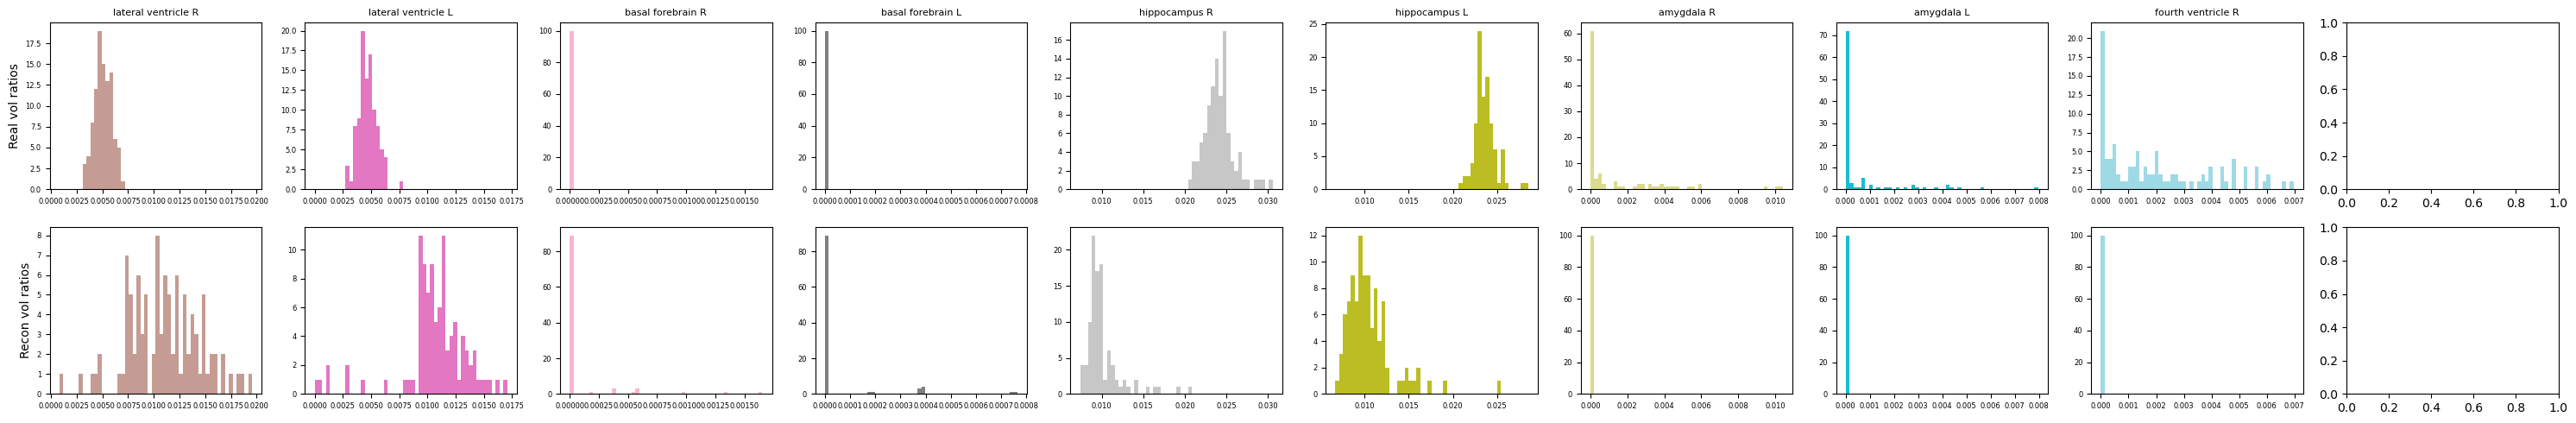

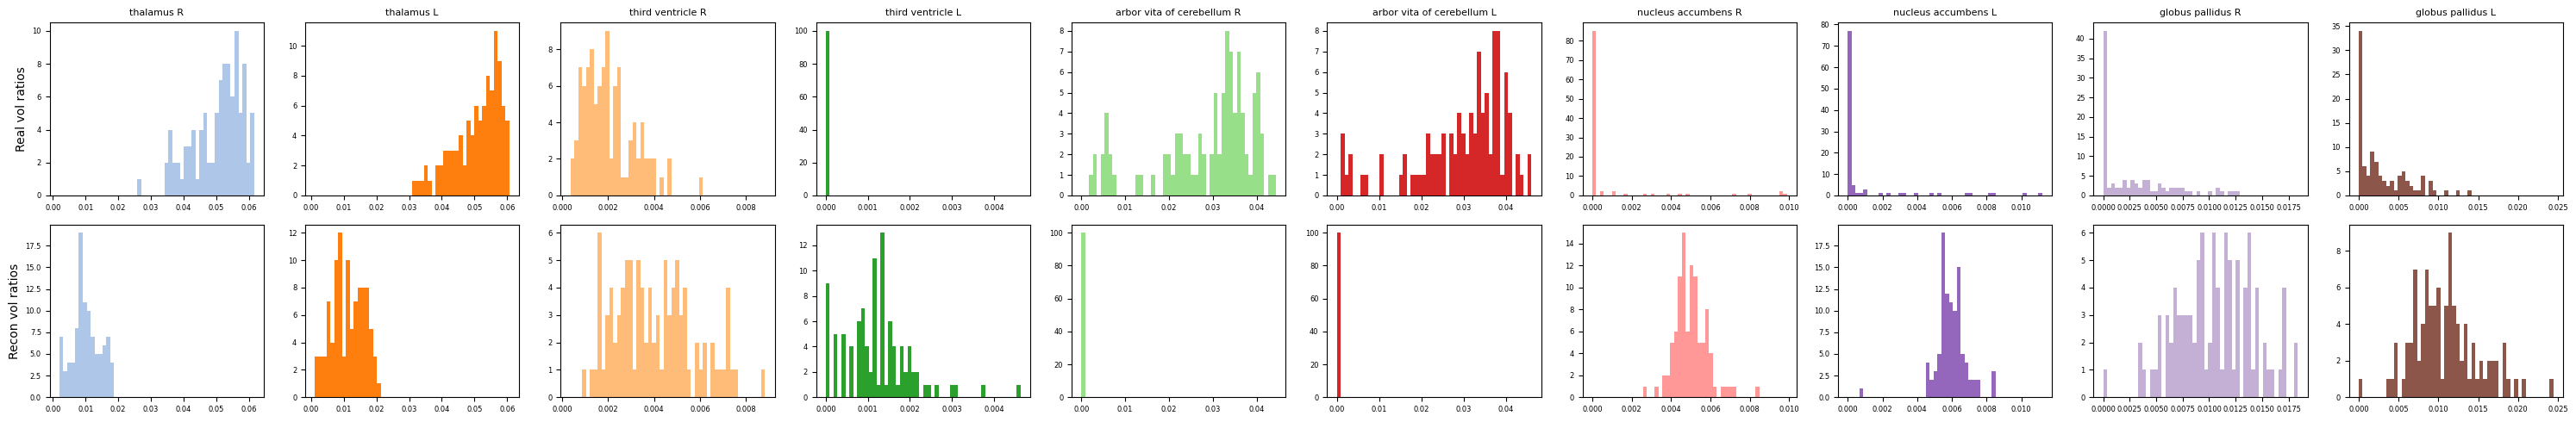

In [15]:
# MOUSE VS HUMAN

real_vol_ratios = compute_common_vol_ratios_from_paths(test_paths[:100])
recon_vol_ratios = compute_common_vol_ratios_from_imgs(trans_imgs)

plot_vol_ratios(real_vol_ratios, recon_vol_ratios, struct_names) # TODO: add in min, max, mean of true distributions

In [ ]:
#img_arr = sitk.GetArrayFromImage(sitk.ReadImage(save_path + "trans_" + test_paths[0].split("/")[-1]))

slice_idx = 80

plot_img_2d(img_arr.squeeze(), "Img")
plot_img_2d(recon_img, "Recon")
plot_img_2d(trans_img, "Trans (no map)")
plot_img_2d(trans_map_img, "Trans (map)")

NameError: name 'img_arr' is not defined

In [ ]:
# SET UP PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pickle

# test PCA translation - set up models
def load_imgs(folder_path):
    images = []
    file_names = []

    for file_name in os.listdir(folder_path):
        img = sitk.ReadImage(folder_path + file_name)
        img_array = sitk.GetArrayFromImage(img)  # Normalize to [0, 1]
        images.append(img_array)

        file_names.append(file_name)

    # Convert to NumPy array: shape (n_images, height, width)
    images = np.stack(images)
    
    return images, file_names

folder_path = "./datasets/2d_larger/"
mouse_train_imgs, mouse_train_file_names = load_imgs(folder_path + "mouse_train/")
mouse_train_imgs_flat = mouse_train_imgs.reshape(len(mouse_train_imgs), -1)
mouse_test_imgs, mouse_test_file_names = load_imgs(folder_path + "mouse_test/")
mouse_test_imgs_flat = mouse_test_imgs.reshape(len(mouse_test_imgs), -1)

human_train_imgs, human_train_file_names = load_imgs(folder_path + "human_train/")
human_train_imgs_flat = human_train_imgs.reshape(len(human_train_imgs), -1)
human_test_imgs, human_test_file_names = load_imgs(folder_path + "human_test/")
human_test_imgs_flat = human_test_imgs.reshape(len(human_test_imgs), -1)

# mouse_data = np.concatenate((mouse_train_imgs_flat, mouse_test_imgs_flat), axis=0)
# human_data = np.concatenate((human_train_imgs_flat, human_test_imgs_flat), axis=0)

# # apply forward
# num_components = 100

# # 1. fit z score normalization: zero-mean, unit variance
# scaler_mouse = StandardScaler()
# mouse_train_scaled = scaler_mouse.fit_transform(mouse_train_imgs_flat)

# scaler_human = StandardScaler()
# human_train_scaled = scaler_human.fit_transform(human_data)

# # 2. fit pca
# pca_mouse = PCA(n_components=num_components, svd_solver='full') # use as encoder
# mouse_train_pca = pca_mouse.fit_transform(mouse_train_scaled)

# pca_human = PCA(n_components=num_components, svd_solver='full') # use as decoder
# human_train_pca = pca_human.fit_transform(human_train_scaled)

# # takes ~10s
# with open("./pca/2d_scaler_100_mouse.pkl", "wb") as f:
#     pickle.dump(scaler_mouse, f)

# with open("./pca/2d_pca_100_mouse.pkl", "wb") as f:
#     pickle.dump(pca_mouse, f)

# with open("./pca/2d_scaler_100_human.pkl", "wb") as f:
#     pickle.dump(scaler_human, f)

# with open("./pca/2d_pca_100_human.pkl", "wb") as f:
#     pickle.dump(pca_human, f)


In [ ]:
# RUNNNNNN
# 3D
import pickle
# load pca and scaler
with open('./pca/3d_larger/final/pca_mouse.pkl', 'rb') as f:
    pca_mouse = pickle.load(f)

with open('./pca/3d_larger/final/scaler_mouse.pkl', 'rb') as f:
    scaler_mouse = pickle.load(f)

with open('./pca/3d_larger/final/pca_human.pkl', 'rb') as f:
    pca_human = pickle.load(f)

with open('./pca/3d_larger/final/scaler_human.pkl', 'rb') as f:
    scaler_human = pickle.load(f)

In [ ]:
# 2D
import pickle
# load pca and scaler
with open("./pca/2d_pca_100_mouse.pkl", 'rb') as f:
    pca_mouse = pickle.load(f)

with open("./pca/2d_scaler_100_mouse.pkl", 'rb') as f:
    scaler_mouse = pickle.load(f)

with open("./pca/2d_pca_100_human.pkl", 'rb') as f:
    pca_human = pickle.load(f)

with open("./pca/2d_scaler_100_human.pkl", 'rb') as f:
    scaler_human = pickle.load(f)

In [ ]:
# RUNNN

def get_matter_ratio(img_arr):
    gm_count = np.sum(img_arr == 1)
    wm_count = np.sum(img_arr == 2)
    csf_count = np.sum(img_arr == 3)
    total = gm_count + wm_count + csf_count

    gm_ratio = gm_count/total
    wm_ratio = wm_count/total
    csf_ratio = csf_count/total

    return gm_ratio, wm_ratio, csf_ratio

def compute_matter_ratios(imgs):
    gm_ratios = []
    wm_ratios = []
    csf_ratios = []

    for img in imgs:
        gm_ratio, wm_ratio, csf_ratio = get_matter_ratio(img)

        gm_ratios.append(gm_ratio)
        wm_ratios.append(wm_ratio)
        csf_ratios.append(csf_ratio)

    return gm_ratios, wm_ratios, csf_ratios

def analyze_matter_ratio_preservation(real, synth, title, color, features_idx):
    # i) Run pearson correlation analysis
    #   - r = measures the linear correlation between two variables
    #   - r = cov(x, y) / (std_x*std_y)
    #   - r = +1 => perfect possitve correlation
    #   - r = -1 => perfect negative correlation
    #   - r = 0 => no correlation
    # The p tests the null hypothesis that there is no correlation between the two
    # variables (p < 0.05 => significant corr, p > 0.05 => correlation could be chance)
    r, p = scipy.stats.pearsonr(real, synth)
    print(f"Pearson's r: {round(r, 4)}, p-value: {round(p, 4)}")

    # ii) Compute coefficent of determination (R^2)
    #   - give the variance of dependent y explained by the independent variable x
    #   - R^2 = 1 - (sum [y_true - y_pred]^2)/(sum [y_true - y_mean]^2)
    #   - R^2 = 1 => perfect prediction
    #   - R^2 = 0 => model explains none of the variance
    #   - R^2 < 0 => model is a bad fit
    real_reshape = np.array(real).reshape(-1, 1)
    synth_reshape = np.array(synth).reshape(-1, 1)
    model = LinearRegression().fit(real_reshape, synth_reshape)
    r_squared = model.score(real_reshape, synth_reshape)
    print(f"R²: {round(r_squared, 4)}")

    model.fit(real_reshape, synth)

    # Predict y values for the regressed line
    y_pred = model.predict(real_reshape)

    # iii) Plot the real versus reconstructed with fitted line overlayed
    plt.figure(figsize=(3,3))
    plt.scatter(real, synth, color=color, s=10)
    plt.plot(real, y_pred, color="black")
    plt.xlabel("Real mouse")
    plt.ylabel("Trans human")
    plt.title(title + " (pr = " + str(round(r, 4)) + ")")
    plt.xlim() # for real mouse
    plt.ylim() # for trans human
    plt.axhline(human_features_means[features_idx], color="grey", lw=1)
    plt.axhline(human_features_mins[features_idx], color="grey", lw=1) 
    plt.axhline(human_features_maxs[features_idx], color="grey", lw=1)
    plt.show()

def compare_ratio_calcs(imgs):
    imgs = torch.from_numpy(imgs)
    gm_ratios_real = get_gm_non_diff(imgs)
    gm_ratios_approx = get_gm_diff(imgs)

    r, p = scipy.stats.pearsonr(gm_ratios_real, gm_ratios_approx)
    print(f"Pearson's r: {round(r, 4)}")
    
    plt.figure(figsize=(3,3))
    plt.scatter(gm_ratios_real, gm_ratios_approx, s=10)
    plt.xlabel("Non diff GM loss (real)")
    plt.ylabel("Diff GM loss (aprox)")
    plt.show()


Pearson's r: 0.1223, p-value: 0.0038
R²: 0.0149


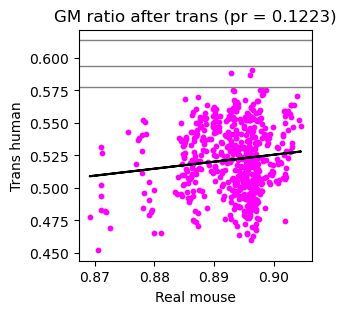

Pearson's r: 0.1433, p-value: 0.0007
R²: 0.0205


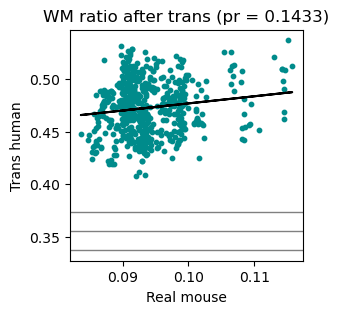

Pearson's r: 0.0381, p-value: 0.368
R²: 0.0015


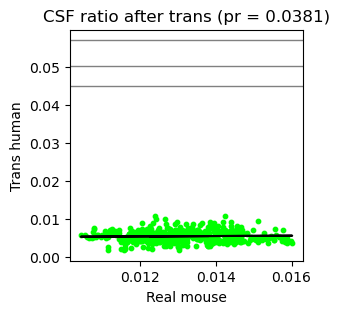

: 

In [ ]:
# RUNN
model = MLP.cuda() 
#model.load_state_dict(torch.load('./pca/gm_loss_mod_500.pth')['model_state_dict'])


mouse_ratios_means, mouse_ratios_stds = dataset.get_mouse_mean_and_std()
train_folder = "./datasets/3d_larger/mouse_train/"
test_folder = "./datasets/3d_larger/mouse_test/"

test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]
test_paths.sort()

train_paths = [train_folder + file_name for file_name in os.listdir(train_folder)]
train_paths.sort()

def quick_analysis(paths):
    # 1 - get image arrs
    mouse_imgs = []
    for path in paths:
        mouse_img = sitk.ReadImage(path)
        mouse_img_arr = sitk.GetArrayFromImage(mouse_img)
        mouse_imgs.append(mouse_img_arr)

    # 2 - apply pca
    mouse_imgs = np.array(mouse_imgs)
    mouse_imgs_arr_flat = mouse_imgs.reshape(mouse_imgs.shape[0], mouse_imgs.shape[1]*mouse_imgs.shape[2]*mouse_imgs.shape[3]) # NOTE: update for 2D/3D
    mouse_imgs_arr_scaled = scaler_mouse.transform(mouse_imgs_arr_flat)
    mouse_pca_encodings = pca_mouse.transform(mouse_imgs_arr_scaled)

    # 3 - map to human encodings
    human_pca_encodings = model(torch.from_numpy(mouse_pca_encodings).cuda())

    # 4 - inverse pcas back to imgs
    human_trans = pca_human.inverse_transform(human_pca_encodings.detach().cpu())
    human_trans_unscale = scaler_human.inverse_transform(human_trans)
    human_imgs_trans = np.clip(np.round(human_trans_unscale.reshape(mouse_imgs.shape)), 0, 3)

    real_gm, real_wm, real_csf = compute_matter_ratios(mouse_imgs)
    trans_gm, trans_wm, trans_csf = compute_matter_ratios(human_imgs_trans)

    # plot
    analyze_matter_ratio_preservation(real_gm, trans_gm, "GM ratio after trans", "magenta", 0)
    analyze_matter_ratio_preservation(real_wm, trans_wm, "WM ratio after trans", "darkcyan", 1)
    analyze_matter_ratio_preservation(real_csf, trans_csf, "CSF ratio after trans", "lime", 2)

    # plot imgs variance
    img_stack = np.stack(human_imgs_trans, axis=0)
    voxel_variance = np.var(img_stack, axis=0)
    plt.figure(figsize=(3,3))
    plt.imshow(voxel_variance[slice_idx], "jet", vmin=0, vmax=2) # NOTE: diff in 2D and 3D
    plt.title("Trans human variance")
    plt.colorbar()
    plt.show()

    # plot the distributions to compare
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    bins = 100

    axs[0, 0].hist(real_human_gm, bins, edgecolor="darkorchid", color="mediumorchid")
    axs[0, 0].set_xlim(min(np.min(real_human_gm), np.min(trans_gm))*0.95, max(np.max(real_human_gm), np.max(trans_gm))*1.05)
    axs[0, 0].set_title('Real human gm')

    axs[1, 0].hist(trans_gm, bins, edgecolor="darkorchid", color="mediumorchid")
    axs[1, 0].set_xlim(min(np.min(real_human_gm), np.min(trans_gm))*0.95, max(np.max(real_human_gm), np.max(trans_gm))*1.05)
    axs[1, 0].set_title('Trans human wm')

    axs[0, 1].hist(real_human_wm, bins, edgecolor="darkslategrey", color="darkcyan")
    axs[0, 1].set_xlim(min(np.min(real_human_wm), np.min(trans_wm))*0.95, max(np.max(real_human_wm), np.max(trans_wm))*1.05)
    axs[0, 1].set_title('Real human csf')

    axs[1, 1].hist(trans_wm, bins, edgecolor="darkslategrey", color="darkcyan")
    axs[1, 1].set_xlim(min(np.min(real_human_wm), np.min(trans_wm))*0.95, max(np.max(real_human_wm), np.max(trans_wm))*1.05)
    axs[1, 1].set_title('Trans human gm')

    axs[0, 2].hist(real_human_csf, bins, edgecolor="seagreen", color="mediumseagreen")
    axs[0, 2].set_xlim(-0.01, max(np.max(real_human_csf), np.max(trans_csf))*1.05)
    axs[0, 2].set_title('Real human wm')

    axs[1, 2].hist(trans_csf, bins, edgecolor="seagreen", color="mediumseagreen")
    axs[1, 2].set_xlim(-0.01, max(np.max(real_human_csf), np.max(trans_csf))*1.05)
    axs[1, 2].set_title('Trans human csf')

    plt.tight_layout()
    plt.show()

    return human_trans_unscale


human_imgs = quick_analysis(test_paths)

0.5199553792761527


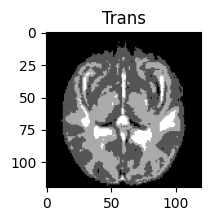

(diff) mouse gm: 0.8511 human_gm: 0.5695
(non diff) mouse gm: 0.8603 human_gm: 0.52
0.5757612667478684


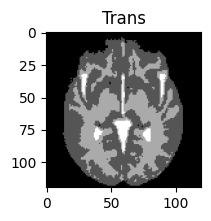

(diff) mouse gm: 0.8636 human_gm: 0.5934
(non diff) mouse gm: 0.8778 human_gm: 0.5758
0.5667345899133979


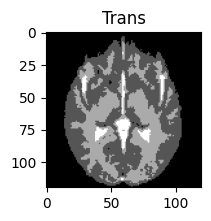

(diff) mouse gm: 0.8582 human_gm: 0.5949
(non diff) mouse gm: 0.8716 human_gm: 0.5667
0.5773666506487266


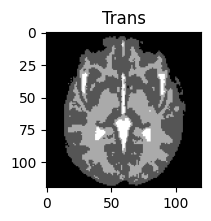

(diff) mouse gm: 0.8642 human_gm: 0.594
(non diff) mouse gm: 0.875 human_gm: 0.5774
0.5751580426129712


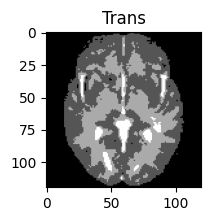

(diff) mouse gm: 0.8643 human_gm: 0.5914
(non diff) mouse gm: 0.8706 human_gm: 0.5752
0.4948721117014704


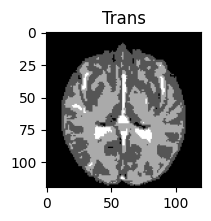

(diff) mouse gm: 0.8351 human_gm: 0.5342
(non diff) mouse gm: 0.8352 human_gm: 0.4949
0.6019923549171783


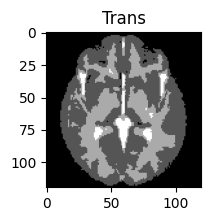

(diff) mouse gm: 0.8785 human_gm: 0.6119
(non diff) mouse gm: 0.8911 human_gm: 0.602
0.5740218324543113


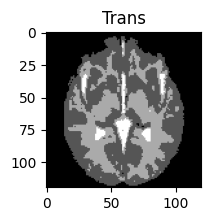

(diff) mouse gm: 0.8646 human_gm: 0.5969
(non diff) mouse gm: 0.877 human_gm: 0.574
0.5688160551003444


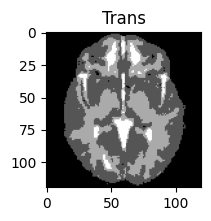

(diff) mouse gm: 0.8656 human_gm: 0.598
(non diff) mouse gm: 0.878 human_gm: 0.5688
0.5885364635364635


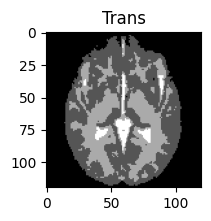

(diff) mouse gm: 0.8725 human_gm: 0.6095
(non diff) mouse gm: 0.8879 human_gm: 0.5885


In [ ]:
mouse_ratios_means, mouse_ratios_stds = dataset.get_mouse_mean_and_std()
folder = "./datasets/2d_larger/mouse_train/"
paths = [folder + file_name for file_name in os.listdir(folder)]
random.shuffle(np.array(paths))
slice_idx = 60

save_path = "./pca/trans_test/"

os.makedirs(save_path, exist_ok=True)

for path in paths[:10]:
    mouse_img = sitk.ReadImage(path)
    mouse_img_arr = sitk.GetArrayFromImage(mouse_img)
    mouse_img_arr_flat = mouse_img_arr.flatten().reshape(1, -1)
    mouse_img_arr_scaled = scaler_mouse.transform(mouse_img_arr_flat)
    mouse_pca_encoding = pca_mouse.transform(mouse_img_arr_scaled)

    # map
    human_pca_encoding = model(torch.from_numpy(mouse_pca_encoding).cuda())

    human_trans = pca_human.inverse_transform(human_pca_encoding.detach().cpu())
    human_trans_unscale = scaler_human.inverse_transform(human_trans)
    human_img_trans = np.clip(np.round(human_trans_unscale.reshape(mouse_img_arr.shape)), 0, 3)

    print(np.sum(human_img_trans == 1) / np.sum(human_img_trans != 0))

    plt.figure(figsize=(2,3))
    plt.imshow(human_img_trans, cmap='gray')
    plt.title("Trans")
    plt.show()

    gm_mouse = get_gm_diff(torch.from_numpy(mouse_img_arr)) 
    gm_human = get_gm_diff(torch.from_numpy(human_trans_unscale))

    gm_mouse_nd = get_gm_non_diff(torch.from_numpy(mouse_img_arr)) 
    gm_human_nd = get_gm_non_diff(torch.from_numpy(human_trans_unscale))

    mouse_gm_norm = (gm_mouse - mouse_ratios_means[0]) / (mouse_ratios_stds[0] + 1e-6)
    human_gm_norm = (gm_human - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)

    print("(diff) mouse gm:", round(gm_mouse.item(), 4), "human_gm:", round(gm_human.item(), 4))
    print("(non diff) mouse gm:", round(gm_mouse_nd.item(), 4), "human_gm:", round(gm_human_nd.item(), 4))

    #trans_map_niffty = sitk.GetImageFromArray(human_img_trans)
    #sitk.WriteImage(trans_map_niffty, save_path + path.split("/")[-1])

# train takes ~7min

[0. 1. 2. 3.]


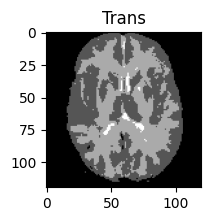

[0. 1. 2. 3.]


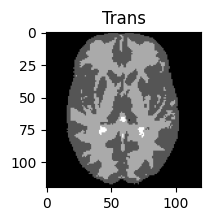

[0. 1. 2. 3.]


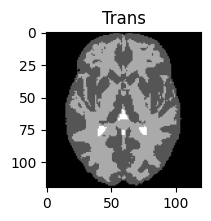

[0. 1. 2. 3.]


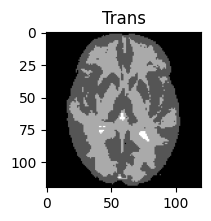

[0. 1. 2. 3.]


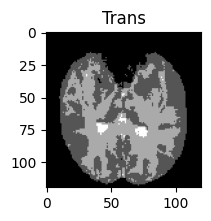

In [ ]:
idxs = [10, 20, 30, 40, 50]

for idx in idxs:
    recon = human_imgs_trans[idx]

    print(np.unique(recon))
    plt.figure(figsize=(2,3))
    plt.imshow(recon, cmap='gray')
    plt.title("Trans")
    plt.show()

In [ ]:

def save_recons(save_path, imgs, file_names):
    os.makedirs(save_path, exist_ok=True)
    for i, img in enumerate(imgs):
        sitk.WriteImage(sitk.GetImageFromArray(img), save_path + file_names[i])

save_path = "./pca/pca_100_MLP_mapping/pca_human_train_100_trans/"
save_recons(save_path, human_imgs_trans, mouse_train_file_names)

print(len(mouse_train_file_names))

2208


### Analyze distribution of latent encodings

Mean of means: 0.4012
Std of means: 0.9908
Mean of stds: 0.2303
Std of stds: 0.1327
Mean of norms: 19.5872
Std of norms: 16.9107


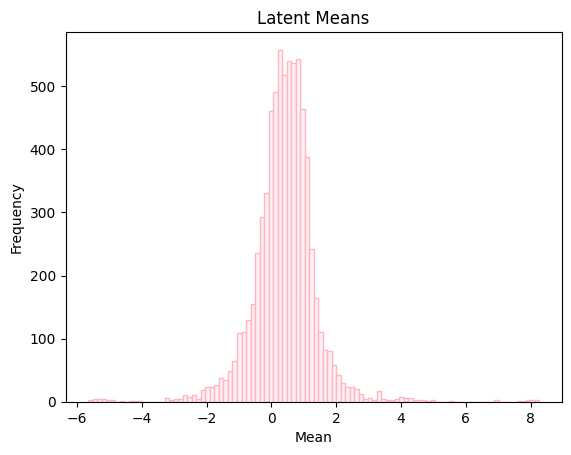

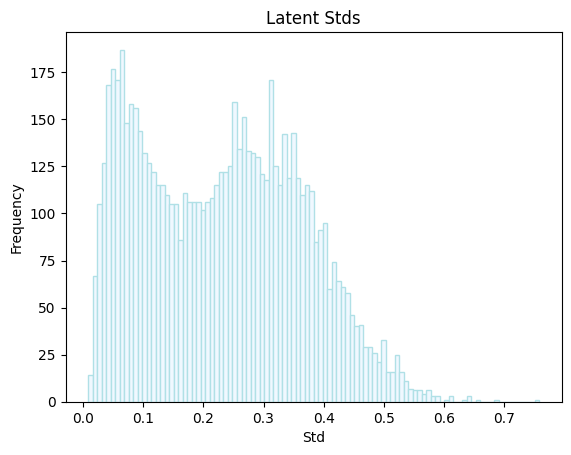

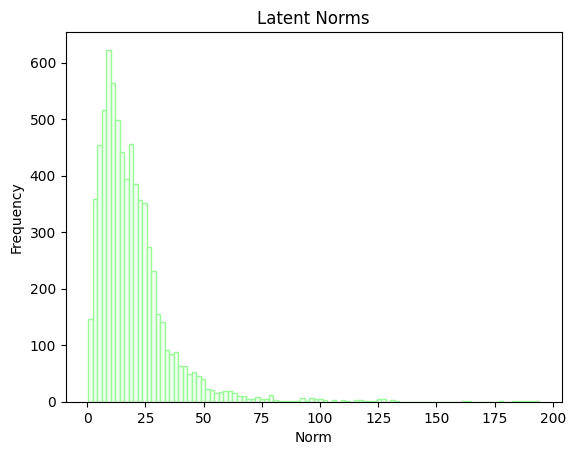

Mean of means: 0.3729
Std of means: 1.1128
Mean of stds: 0.2813
Std of stds: 0.1377
Mean of norms: 20.5682
Std of norms: 19.7813


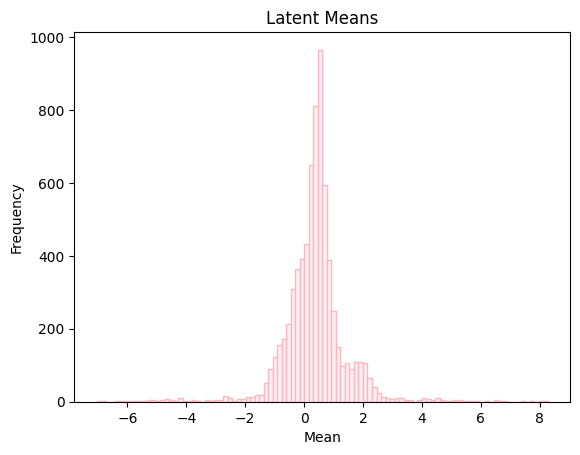

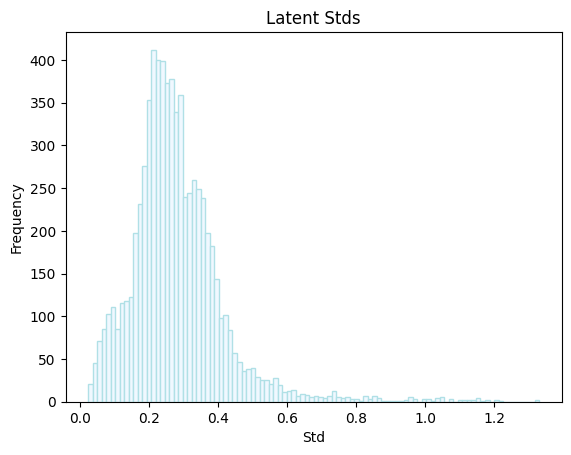

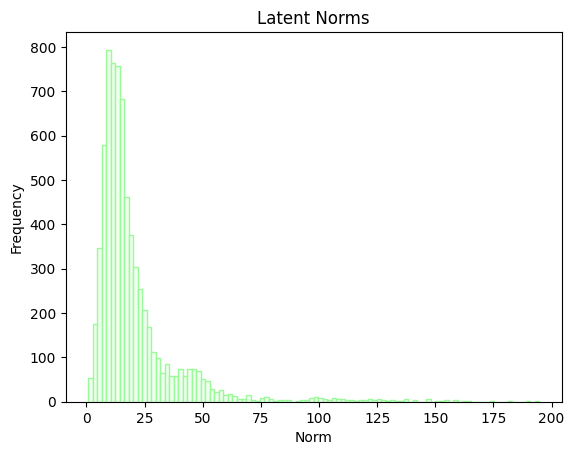

In [ ]:
# Dataset
mouse_encodings_folder = "./save_2d/2d_larger/mouse_train_1/train_latent_encodings/"
human_encodings_folder = "./save_2d/2d_larger/human_train_1/train_latent_encodings/"

mouse_test_encodings_folder = "./save_2d/2d_larger/mouse_train_1/test_latent_encodings/"
human_test_encodings_folder = "./save_2d/2d_larger/human_train_1/test_latent_encodings/"

dataset = LatentVectorDataset(mouse_test_encodings_folder, human_test_encodings_folder)
batch_size = dataset.__len__() # known num of train vectors
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

mouse_batch, human_batch = next(iter(dataloader))

def plot_latent_vect_dists(encodings):
    means = encodings.mean(dim=0)
    stds = encodings.std(dim=0)
    norms = encodings.norm(dim=0)

    print("Mean of means:", np.round(means.mean().numpy(), 4))
    print("Std of means:", np.round(means.std().numpy(), 4))

    print("Mean of stds:", np.round(stds.mean().numpy(), 4))
    print("Std of stds:", np.round(stds.std().numpy(), 4))

    print("Mean of norms:", np.round(norms.mean().numpy(), 4))
    print("Std of norms:", np.round(norms.std().numpy(), 4))

    plt.hist(means, bins=100, edgecolor="lightpink", color="lavenderblush")
    plt.xlabel("Mean")
    plt.ylabel("Frequency")
    plt.title("Latent Means")
    plt.show()

    plt.hist(stds, bins=100, edgecolor="powderblue", color="aliceblue")
    plt.xlabel("Std")
    plt.ylabel("Frequency")
    plt.title("Latent Stds")
    plt.show()

    plt.hist(norms, bins=100, edgecolor="palegreen", color="honeydew")
    plt.xlabel("Norm")
    plt.ylabel("Frequency")
    plt.title("Latent Norms")
    plt.show()

    return means, stds

mouse_means, mouse_stds = plot_latent_vect_dists(mouse_batch)
human_means, human_stds = plot_latent_vect_dists(human_batch)
